<a href="https://colab.research.google.com/github/hmnaz213/native/blob/main/saed_postpaid_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
from google.colab import auth
import gspread
from google.auth import default

# 1. Authenticate user (this will prompt you to allow access)
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# 2. Open the Google Sheet by its title
sheet_title = 'postpaid august 2025'
worksheet = gc.open(sheet_title).sheet1
rows = worksheet.get_all_values()

# 3. Load data into a DataFrame
# Assuming the first row contains headers
df = pd.DataFrame.from_records(rows[1:], columns=rows[0])
display(df.head())

,NO,Region,,District,Billing Period,From Date,,To Date,Document#,Customer,...,Tariff,VAT,Itinerary,Total Amount,Pending Amount,Billed Consumption,Anomalies,Supply Address,,Pole Number
0,1,EASTERN PROVINCE,,41-KENEMA,8-August 2025,2025-08-01,,2025-08-31,UTIL$4410323,CAPITOL FOOD LIMITED,...,T4-MDI – Postpayment-Monthly,0,3301 KENEMA-00001,310.4,310.4,0,Y,"51 HANGA ROAD,9382,-,41-KENEMA",,1000000025
1,2,EASTERN PROVINCE,,41-KENEMA,8-August 2025,2025-08-01,,2025-08-31,UTIL$44107877,THE MANAGER BSL,...,T4-MDI – Postpayment-Monthly,4 342.11,4004-AMRMDI FREETO-00001,33 534.84,33 534.84,4 943.20,N,"2 DAMA ROAD,9383,-,41-KENEMA",,1000000002
2,3,EASTERN PROVINCE,,41-KENEMA,8-August 2025,2025-08-01,,2025-08-31,UTIL$44110376,CAPITOL FOODS LIMITED,...,T4-MDI – Postpayment-Monthly,15 865.31,4004-AMRMDI FREETO-00001,122 074.55,122 074.55,18 061.60,N,"TISSOR VILLAGE,9385,-,41-KENEMA",,1000000002
3,4,EASTERN PROVINCE,,41-KENEMA,8-August 2025,2025-08-01,,2025-08-31,PREP$1-41-97778,"SKAIKAY, AMIN",...,T4-MDI – Postpayment-Monthly,1 423.96,4004-AMRMDI FREETO-00001,10 998.00,10 998.00,1 621.08,Y,",41, 227 HANGA ROAD,6030,STREET,41-KENEMA",,1000000002
4,5,EASTERN PROVINCE,,41-KENEMA,8-August 2025,2025-08-01,,2025-08-31,PREP$2-41-01287RR,ROKELCOMMERCIALBANK SL EDSA54320002246,...,T4-MDI – Postpayment-Monthly,2 147.32,4004-AMRMDI FREETO-00001,16 842.78,16 842.78,2 444.58,N,"41, 12 DAMA RD",,1000000002


In [4]:
num_fields = len(df.columns)
print(f"We have {num_fields} fields (columns) in the dataset.")
print("\nList of fields:")
for col in df.columns:
    print(f"- {col}")

We have 39 fields (columns) in the dataset.

List of fields:
- NO
- Region
- 
- District
- Billing Period
- From Date
- 
- To Date
- Document#
- Customer
- 
- 
- Account#
- Invoice#
- 
- Bill #
- 
- Generation Date
- Issue Date
- 
- Due Date
- Cancel Date
- Service
- Contracted Service Status
- 
- Billing Type
- Bill Type
- Billing Status
- Collection Status
- Tariff
- VAT
- Itinerary
- Total Amount
- Pending Amount
- Billed Consumption
- Anomalies
- Supply Address
- 
- Pole Number


In [5]:
# Clean the 'Billed Consumption' column by removing spaces, then convert to numeric
numeric_consumption = pd.to_numeric(df['Billed Consumption'].astype(str).str.replace(' ', ''), errors='coerce')

# Filter the dataframe where the numeric consumption is exactly 0
df_zero_consumption = df[numeric_consumption == 0]

print(f"Number of records with 0 billed consumption: {len(df_zero_consumption)}")
display(df_zero_consumption.head())

Number of records with 0 billed consumption: 1267


,NO,Region,,District,Billing Period,From Date,,To Date,Document#,Customer,...,Tariff,VAT,Itinerary,Total Amount,Pending Amount,Billed Consumption,Anomalies,Supply Address,,Pole Number
0,1,EASTERN PROVINCE,,41-KENEMA,8-August 2025,2025-08-01,,2025-08-31,UTIL$4410323,CAPITOL FOOD LIMITED,...,T4-MDI – Postpayment-Monthly,0,3301 KENEMA-00001,310.4,310.4,0,Y,"51 HANGA ROAD,9382,-,41-KENEMA",,1000000025
6,7,EASTERN PROVINCE,,41-KENEMA,8-August 2025,2025-08-01,,2025-08-31,PREP$2-41-101041,"FAWAZ, ABDUL HAMID",...,T4-MDI – Postpayment-Monthly,0,4004-AMRMDI FREETO-00001,162,0,0,N,",TISSOR LAYOUT HANGA ROAD KENEM,8060,STREET,41...",,1000000002
7,8,EASTERN PROVINCE,,41-KENEMA,8-August 2025,2025-08-01,,2025-08-31,PREP$2-41-10798,COUNCIL DISTRICT KENEMA,...,T4-MDI – Postpayment-Monthly,0,4004-AMRMDI FREETO-00001,162,162,0,N,"41, NYANDEYAMA ROAD KENEMA",,1000000002
11,12,EASTERN PROVINCE,,41-KENEMA,8-August 2025,2025-08-01,,2025-08-31,PREP$2-41-98375,ALBERTSON HOTEL,...,T4-MDI – Postpayment-Monthly,0,4004-AMRMDI FREETO-00001,162,162,0,N,",NYANDEYAMA ROAD, KENEMA,8914,STREET,41-KENEMA",,1000000002
21,22,EASTERN PROVINCE,,41-KENEMA,8-August 2025,2025-08-01,,2025-08-31,SLDL00470,PS OFFICE,...,T2-Commercial – Postpayment,0,3301 KENEMA-00001,18,18,0,Y,"OFFICE,GOVT. RESERVATION,21,KENEMA,41-KENEMA",,1000000002


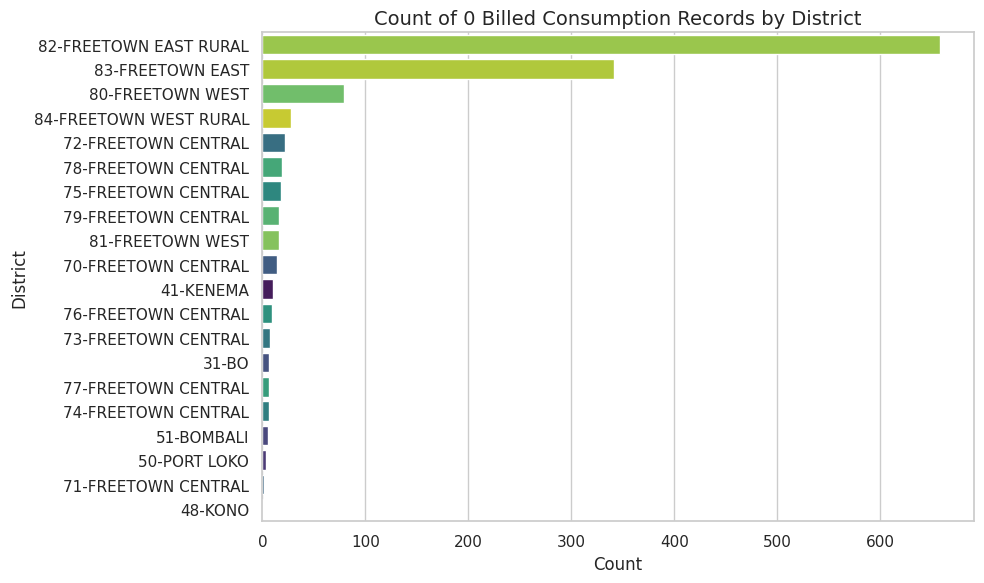

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

# Create a figure and axis
plt.figure(figsize=(10, 6))

# Create a count plot for the 'District' column
sns.countplot(data=df_zero_consumption, y='District', hue='District', order=df_zero_consumption['District'].value_counts().index, palette='viridis', legend=False)

# Add titles and labels
plt.title('Count of 0 Billed Consumption Records by District', fontsize=14)
plt.xlabel('Count', fontsize=12)
plt.ylabel('District', fontsize=12)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

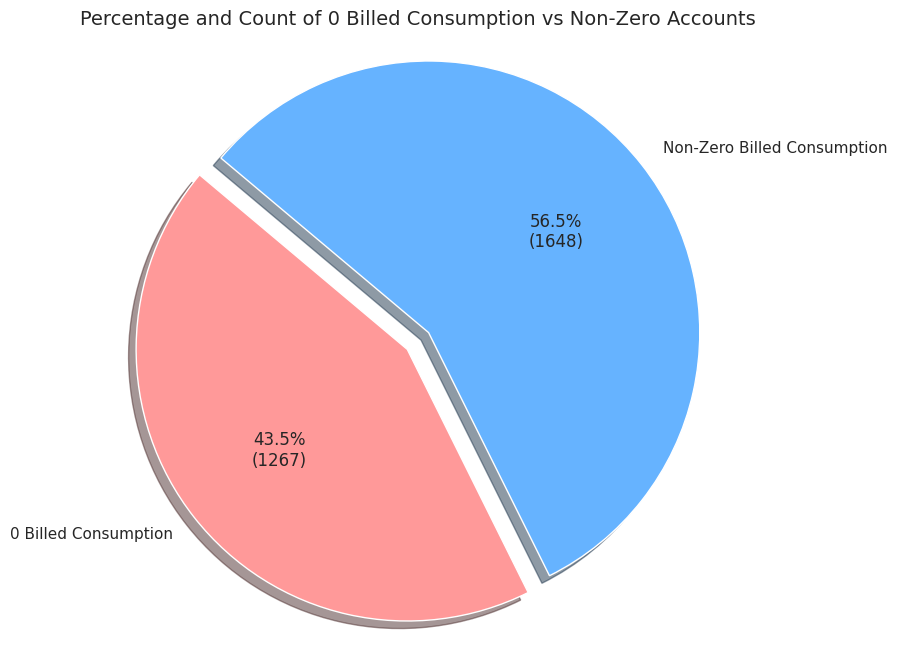

In [9]:
import matplotlib.pyplot as plt

# Calculate counts
total_accounts = len(df)
zero_consumption_count = len(df_zero_consumption)
non_zero_count = total_accounts - zero_consumption_count

# Data to plot
labels = ['0 Billed Consumption', 'Non-Zero Billed Consumption']
sizes = [zero_consumption_count, non_zero_count]
colors = ['#ff9999', '#66b3ff']
explode = (0.1, 0)  # slightly explode the 0 consumption slice for emphasis

# Custom autopct to show both percentage and count
def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({val:d})'
    return my_format

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct=autopct_format(sizes), shadow=True, startangle=140)

# Add title
plt.title('Percentage and Count of 0 Billed Consumption vs Non-Zero Accounts', fontsize=14)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Show the plot
plt.show()

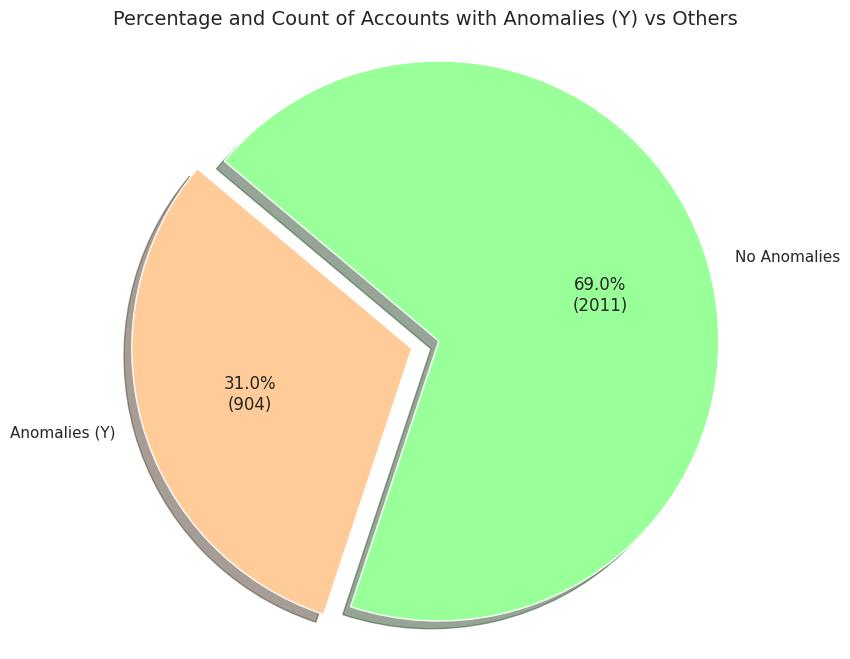

In [10]:
import matplotlib.pyplot as plt

# Safely check for 'Y' in the 'Anomalies' column (handling any extra spaces or casing)
anomalies_y_mask = df['Anomalies'].astype(str).str.strip().str.upper() == 'Y'
anomalies_y_count = anomalies_y_mask.sum()
total_accounts = len(df)
non_anomalies_count = total_accounts - anomalies_y_count

# Data to plot
labels = ['Anomalies (Y)', 'No Anomalies']
sizes = [anomalies_y_count, non_anomalies_count]
colors = ['#ffcc99', '#99ff99']
explode = (0.1, 0)  # slightly explode the Anomalies slice for emphasis

# Custom autopct to show both percentage and count
def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({val:d})'
    return my_format

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct=autopct_format(sizes), shadow=True, startangle=140)

# Add title
plt.title('Percentage and Count of Accounts with Anomalies (Y) vs Others', fontsize=14)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Show the plot
plt.show()

In [11]:
# Filter the zero consumption dataframe for 'Y' in 'Anomalies'
both_conditions_mask = df_zero_consumption['Anomalies'].astype(str).str.strip().str.upper() == 'Y'
accounts_both = df_zero_consumption[both_conditions_mask]

num_both = len(accounts_both)
print(f"Number of accounts with BOTH 0 billed consumption and 'Y' anomaly: {num_both}")

Number of accounts with BOTH 0 billed consumption and 'Y' anomaly: 241


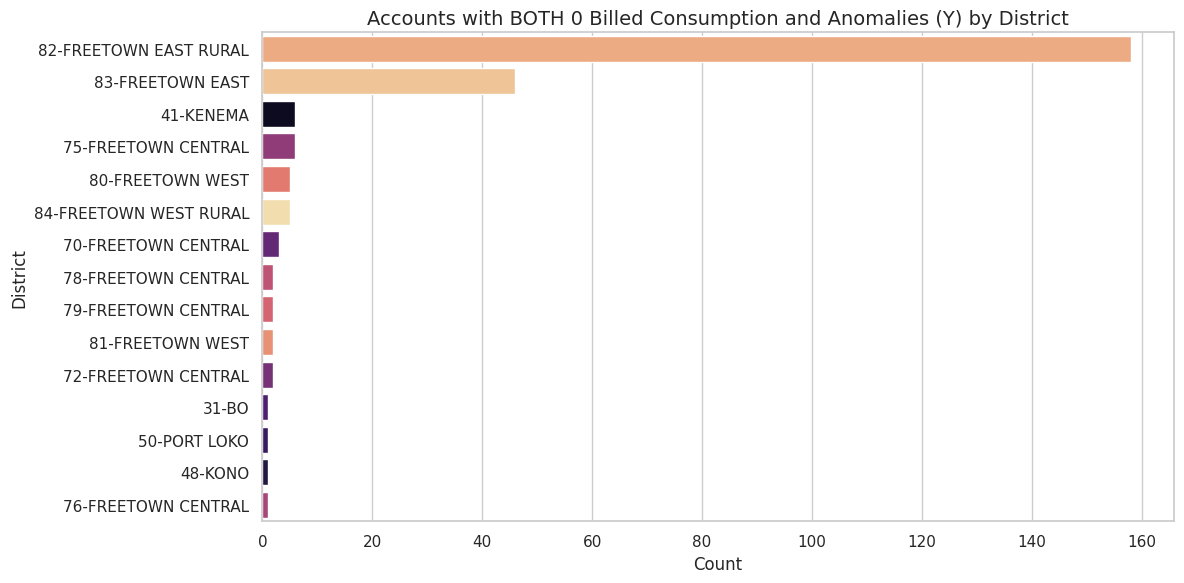

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

# Create a figure and axis
plt.figure(figsize=(12, 6))

# Create a count plot for the 'District' column for these specific accounts
sns.countplot(data=accounts_both, y='District', hue='District',
              order=accounts_both['District'].value_counts().index,
              palette='magma', legend=False)

# Add titles and labels
plt.title('Accounts with BOTH 0 Billed Consumption and Anomalies (Y) by District', fontsize=14)
plt.xlabel('Count', fontsize=12)
plt.ylabel('District', fontsize=12)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

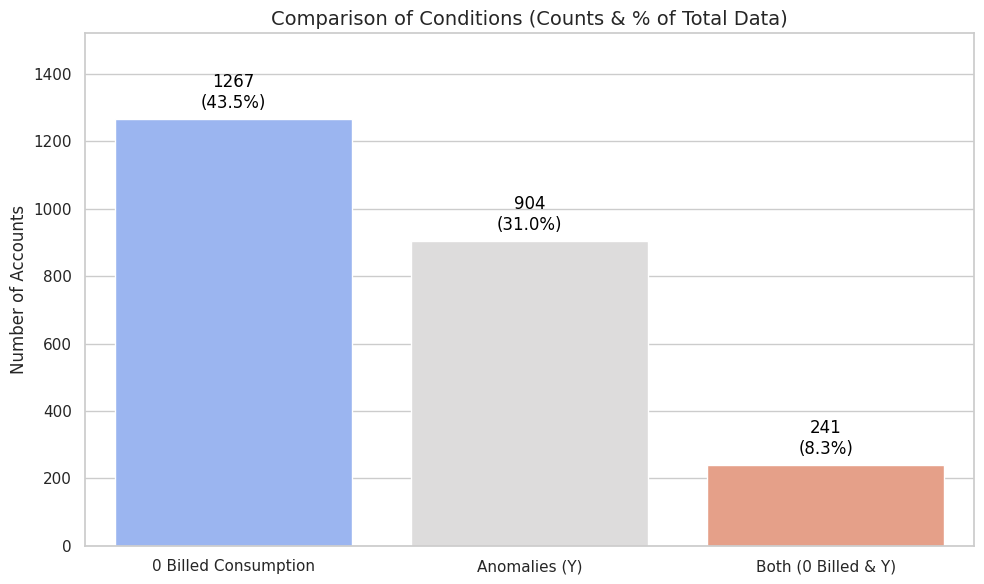

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data for bar plot
categories = ['0 Billed Consumption', 'Anomalies (Y)', 'Both (0 Billed & Y)']
counts = [zero_consumption_count, anomalies_y_count, num_both]
percentages = [(c / total_accounts) * 100 for c in counts]

plt.figure(figsize=(10, 6))
# Create a bar plot, assigning hue to categories to avoid warnings
ax = sns.barplot(x=categories, y=counts, hue=categories, palette='coolwarm', legend=False)

# Add count and percentage labels on top of the bars
for i, p in enumerate(ax.patches):
    ax.annotate(f"{counts[i]}\n({percentages[i]:.1f}%)",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Comparison of Conditions (Counts & % of Total Data)', fontsize=14)
plt.ylabel('Number of Accounts', fontsize=12)
plt.ylim(0, max(counts) * 1.2)  # Add some extra space on top for the labels

plt.tight_layout()
plt.show()

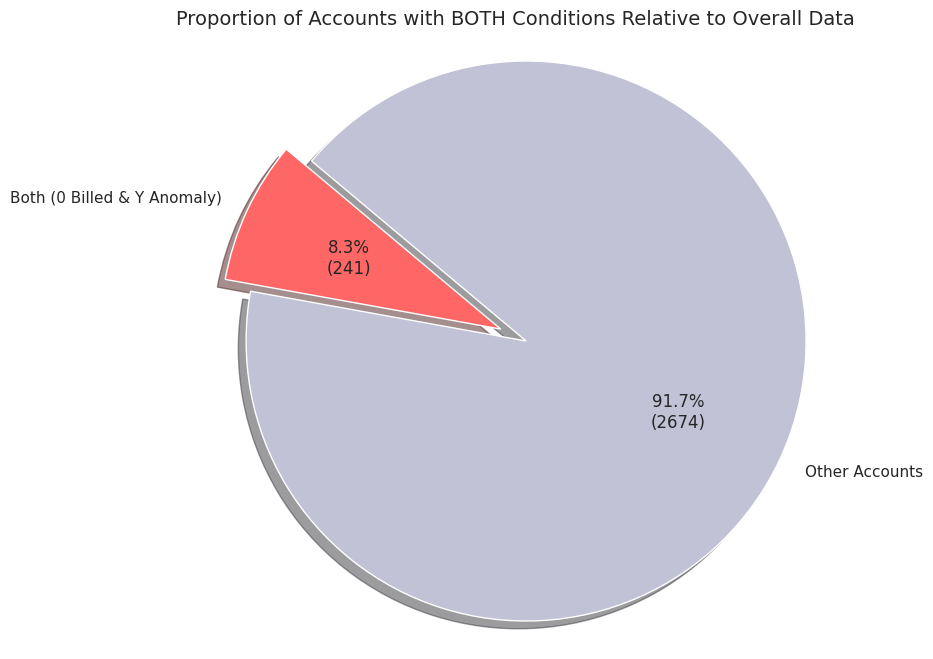

In [14]:
import matplotlib.pyplot as plt

# Data for the pie chart
rest_of_data = total_accounts - num_both
sizes_pie = [num_both, rest_of_data]
labels_pie = ['Both (0 Billed & Y Anomaly)', 'Other Accounts']
colors_pie = ['#ff6666', '#c2c2d6']
explode_pie = (0.1, 0)  # slightly explode the 'Both' slice

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(sizes_pie, explode=explode_pie, labels=labels_pie, colors=colors_pie,
        autopct=lambda pct: f'{pct:.1f}%\n({int(round(pct * sum(sizes_pie) / 100.0))})',
        shadow=True, startangle=140)

# Add title
plt.title('Proportion of Accounts with BOTH Conditions Relative to Overall Data', fontsize=14)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.show()

In [16]:
# 1. Inspect unique values in 'Contracted Service Status'
print("Value counts for 'Contracted Service Status':")
display(df['Contracted Service Status'].value_counts())

# 2. Filter for accounts that are pending termination (case-insensitive search)
term_mask = df['Contracted Service Status'].astype(str).str.contains('pending term|terminat', case=False, na=False)
df_pending_term = df[term_mask]

print(f"\nNumber of accounts related to termination: {len(df_pending_term)}")

if len(df_pending_term) > 0:
    # 3. Analyze potential anomalies across other fields for this subset

    # A. Official Anomalies Flag
    print("\n--- Official 'Anomalies' Flag ---")
    display(df_pending_term['Anomalies'].value_counts())

    # B. Billed Consumption
    print("\n--- Billed Consumption ---")
    # Using the previously cleaned 'numeric_consumption' series
    term_consumption = numeric_consumption[term_mask]
    print(f"Exactly 0 Consumption: {(term_consumption == 0).sum()} accounts")
    print(f"Greater than 0 Consumption: {(term_consumption > 0).sum()} accounts")

    # C. Collection Status
    print("\n--- Collection Status ---")
    display(df_pending_term['Collection Status'].value_counts())

    # D. Pending Amount
    print("\n--- Pending Amount ---")
    # Clean the 'Pending Amount' column (remove spaces and commas, convert to float)
    pending_amt = pd.to_numeric(df_pending_term['Pending Amount'].astype(str).str.replace(' ', '').str.replace(',', ''), errors='coerce')
    print(f"Accounts with Pending Amount > 0: {(pending_amt > 0).sum()}")
    print(f"Accounts with Pending Amount <= 0 (No Debt): {(pending_amt <= 0).sum()}")

    # E. Let's look at accounts that are pending termination but have >0 consumption (Logical Anomaly)
    if (term_consumption > 0).sum() > 0:
        print("\n--- POTENTIAL ANOMALY: Pending Termination but > 0 Billed Consumption ---")
        display(df_pending_term[term_consumption > 0][['Account#', 'Contracted Service Status', 'Billed Consumption', 'Anomalies']].head())
else:
    print("\nNo accounts found with a status related to 'pending termination'.")

Value counts for 'Contracted Service Status':


,count
Contracted Service Status,
Active,2895
Pending termination,20



Number of accounts related to termination: 20

--- Official 'Anomalies' Flag ---


,count
Anomalies,
N,12
Y,8



--- Billed Consumption ---
Exactly 0 Consumption: 11 accounts
Greater than 0 Consumption: 9 accounts

--- Collection Status ---


,count
Collection Status,
Invoiced,20



--- Pending Amount ---
Accounts with Pending Amount > 0: 20
Accounts with Pending Amount <= 0 (No Debt): 0

--- POTENTIAL ANOMALY: Pending Termination but > 0 Billed Consumption ---


,Account#,Contracted Service Status,Billed Consumption,Anomalies
1,1000037628,Pending termination,4 943.20,N
242,500334800,Pending termination,94,Y
717,500547928,Pending termination,27.2,Y
1899,500330485,Pending termination,143,Y
1903,500331194,Pending termination,143,Y


In [ ]:
# Filter for accounts pending termination with consumption > 0
anomalous_pending_term = df_pending_term[term_consumption > 0]

# Select key columns for clarity
columns_to_show = ['Account#', 'Customer', 'Contracted Service Status', 'Billed Consumption', 'Anomalies', 'Pending Amount']

# Display the clean table
print(f"Found {len(anomalous_pending_term)} accounts pending termination with Billed Consumption > 0:\n")
display(anomalous_pending_term[columns_to_show])

In [18]:
csv_filename = 'anomalous_pending_termination_accounts.csv'

# Redefine the dataframe in case it's missing from the kernel state
anomalous_pending_term = df_pending_term[term_consumption > 0]

# Save the dataframe to a CSV file
anomalous_pending_term.to_csv(csv_filename, index=False)
print(f"Successfully saved {len(anomalous_pending_term)} records to {csv_filename}.")

# Trigger a download of the file to your local machine
from google.colab import files
files.download(csv_filename)

Successfully saved 9 records to anomalous_pending_termination_accounts.csv.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
import pandas as pd
import numpy as np

# Ensure numeric types for calculations
summary_consumption = pd.to_numeric(anomalous_pending_term['Billed Consumption'].astype(str).str.replace(' ', ''), errors='coerce').fillna(0)
summary_pending_amt = pd.to_numeric(anomalous_pending_term['Pending Amount'].astype(str).str.replace(' ', '').str.replace(',', ''), errors='coerce').fillna(0)

print("="*65)
print("SUMMARY REPORT: ACCOUNTS PENDING TERMINATION WITH > 0 CONSUMPTION")
print("="*65)

print(f"Total Accounts Detected: {len(anomalous_pending_term)}")
print(f"Total Billed Consumption: {summary_consumption.sum():,.2f}")
print(f"Total Pending Amount (Debt): {summary_pending_amt.sum():,.2f}")

print("\n--- Official 'Anomalies' Flag (Y/N) ---")
# Standardize formatting just in case
flags = anomalous_pending_term['Anomalies'].astype(str).str.strip().str.upper()
print(flags.value_counts().to_string())

print("\n--- Breakdown by District ---")
districts = anomalous_pending_term['District'].value_counts()
print(districts.to_string())

print("\n--- Summary Statistics for Billed Consumption ---")
display(pd.DataFrame({'Billed Consumption': summary_consumption}).describe().T)


SUMMARY REPORT: ACCOUNTS PENDING TERMINATION WITH > 0 CONSUMPTION
Total Accounts Detected: 9
Total Billed Consumption: 5,685.28
Total Pending Amount (Debt): 38,753.32

--- Official 'Anomalies' Flag (Y/N) ---
Anomalies
Y    6
N    3

--- Breakdown by District ---
District
82-FREETOWN EAST RURAL    4
83-FREETOWN EAST          2
41-KENEMA                 1
80-FREETOWN WEST          1
72-FREETOWN CENTRAL       1

--- Summary Statistics for Billed Consumption ---


,count,mean,std,min,25%,50%,75%,max
Billed Consumption,9.0,631.697778,1617.433335,14.88,94.0,109.0,143.0,4943.2


In [20]:
# 1. Inspect unique values in 'Billing Status'
print("Value counts for 'Billing Status':")
display(df['Billing Status'].value_counts())

# 2. Analyze relationship between Billing Status and Billed Consumption
# We use the 'numeric_consumption' series we cleaned earlier
temp_df = df[['Account#', 'Billing Status', 'Anomalies']].copy()
temp_df['Numeric Consumption'] = numeric_consumption

print("\n--- Summary of Billed Consumption by Billing Status ---")
display(temp_df.groupby('Billing Status')['Numeric Consumption'].describe())


Value counts for 'Billing Status':


,count
Billing Status,
Invoiced,2802
Generated,113



--- Summary of Billed Consumption by Billing Status ---


,count,mean,std,min,25%,50%,75%,max
Billing Status,,,,,,,,
Generated,113.0,1.168142,6.247718,0.0,0.0,0.0,0.0,42.0
Invoiced,2802.0,3034.595489,20596.311457,0.0,0.0,34.0,167.0,745305.0


In [21]:
# Create a mask for 'Generated' status and consumption > 0
generated_anomaly_mask = (df['Billing Status'] == 'Generated') & (numeric_consumption > 0)
anomalous_generated_accounts = df[generated_anomaly_mask].copy()

# Add the cleaned consumption for display clarity
anomalous_generated_accounts['Cleaned Consumption'] = numeric_consumption[generated_anomaly_mask]

# Define the columns to show for better readability
columns_to_show = ['Account#', 'Customer', 'District', 'Billing Status', 'Cleaned Consumption', 'Anomalies', 'Pending Amount']

print(f"Found {len(anomalous_generated_accounts)} anomalous accounts with 'Generated' status and > 0 consumption:\n")
display(anomalous_generated_accounts[columns_to_show])

Found 4 anomalous accounts with 'Generated' status and > 0 consumption:



,Account#,Customer,District,Billing Status,Cleaned Consumption,Anomalies,Pending Amount
2462,500177932,"KAMARA, KADIE",83-FREETOWN EAST,Generated,35.0,N,182.85
2463,500177940,"WURIE B, MAMADU",83-FREETOWN EAST,Generated,42.0,N,216.83
2589,500260286,"KING NATHANIEL, CLAUDIUS",83-FREETOWN EAST,Generated,24.0,N,129.47
2612,500305206,"SESAY, FATMATA",83-FREETOWN EAST,Generated,31.0,N,163.44


In [22]:
csv_filename_generated = 'anomalous_generated_accounts.csv'

# Save the dataframe to a CSV file
anomalous_generated_accounts.to_csv(csv_filename_generated, index=False)
print(f"Successfully saved {len(anomalous_generated_accounts)} records to {csv_filename_generated}.")

# Trigger a download of the file to your local machine
from google.colab import files
files.download(csv_filename_generated)

Successfully saved 4 records to anomalous_generated_accounts.csv.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
# 1. Inspect unique values in 'Collection Status'
print("Value counts for 'Collection Status':")
display(df['Collection Status'].value_counts(dropna=False))

# 2. Clean the 'Pending Amount' column for the entire dataframe so we can analyze it
df['Numeric Pending Amount'] = pd.to_numeric(df['Pending Amount'].astype(str).str.replace(' ', '').str.replace(',', ''), errors='coerce').fillna(0)

# 3. Create a temporary dataframe to summarize metrics by Collection Status
temp_coll_df = df[['Account#', 'Collection Status', 'Anomalies']].copy()
temp_coll_df['Numeric Consumption'] = numeric_consumption
temp_coll_df['Numeric Pending Amount'] = df['Numeric Pending Amount']

print("\n--- Summary of Pending Amount (Debt) by Collection Status ---")
display(temp_coll_df.groupby('Collection Status')['Numeric Pending Amount'].describe())

print("\n--- Summary of Billed Consumption by Collection Status ---")
display(temp_coll_df.groupby('Collection Status')['Numeric Consumption'].describe())

Value counts for 'Collection Status':


,count
Collection Status,
Invoiced,2748
,113
Paid,54



--- Summary of Pending Amount (Debt) by Collection Status ---


,count,mean,std,min,25%,50%,75%,max
Collection Status,,,,,,,,
,113.0,93.246283,224.242962,13.0,13.0,13.00,26.00,1463.60
Invoiced,2748.0,20067.716925,139140.064371,13.0,13.0,192.56,886.54,5021192.89
Paid,54.0,0.000000,0.000000,0.0,0.0,0.00,0.00,0.00



--- Summary of Billed Consumption by Collection Status ---


,count,mean,std,min,25%,50%,75%,max
Collection Status,,,,,,,,
,113.0,1.168142,6.247718,0.0,0.0,0.00,0.00,42.0
Invoiced,2748.0,3040.565422,20783.847079,0.0,0.0,34.00,155.25,745305.0
Paid,54.0,2730.792222,5468.150277,0.0,0.0,244.78,2939.96,25437.4


In [24]:
# 1. Analyze Blank Collection Status
blank_mask = df['Collection Status'].astype(str).str.strip() == ''
df_blank_collection = df[blank_mask].copy()

print("--- Accounts with BLANK Collection Status ---")
print(f"Total Count: {len(df_blank_collection)}")

if len(df_blank_collection) > 0:
    df_blank_collection['Cleaned Consumption'] = numeric_consumption[blank_mask]

    print("\nSummary of Debt (Pending Amount) for Blank Status:")
    display(df_blank_collection['Numeric Pending Amount'].describe())

    print("\nSample of Blank Collection Status accounts with Debt > 0:")
    columns_to_show_blank = ['Account#', 'Collection Status', 'Billing Status', 'Cleaned Consumption', 'Numeric Pending Amount', 'Anomalies']
    display(df_blank_collection[df_blank_collection['Numeric Pending Amount'] > 0][columns_to_show_blank].head(10))

# 2. Analyze 'Paid' Collection Status
paid_mask = df['Collection Status'].astype(str).str.strip().str.lower() == 'paid'
df_paid = df[paid_mask].copy()

print("\n=========================================================")
print("--- Accounts with 'PAID' Collection Status ---")
print(f"Total Count: {len(df_paid)}")

if len(df_paid) > 0:
    df_paid['Cleaned Consumption'] = numeric_consumption[paid_mask]

    print("\nSummary of Billed Consumption for Paid Status:")
    display(df_paid['Cleaned Consumption'].describe())

    print("\nSample of Paid Collection Status accounts:")
    columns_to_show_paid = ['Account#', 'Collection Status', 'Billing Status', 'Cleaned Consumption', 'Pending Amount', 'Anomalies']
    display(df_paid[columns_to_show_paid].head(10))

--- Accounts with BLANK Collection Status ---
Total Count: 113

Summary of Debt (Pending Amount) for Blank Status:


,Numeric Pending Amount
count,113.000000
mean,93.246283
std,224.242962
min,13.000000
25%,13.000000
50%,13.000000
75%,26.000000
max,1463.600000



Sample of Blank Collection Status accounts with Debt > 0:


,Account#,Collection Status,Billing Status,Cleaned Consumption,Numeric Pending Amount,Anomalies
7,1002635969,,Generated,0.0,162.0,N
101,500357694,,Generated,0.0,760.0,N
123,1000037580,,Generated,0.0,760.0,N
150,500370572,,Generated,0.0,860.0,N
158,1000038442,,Generated,0.0,372.4,N
159,1000038455,,Generated,0.0,372.4,N
206,500657537,,Generated,0.0,13.0,N
225,500177841,,Generated,0.0,13.0,N
227,500177924,,Generated,0.0,13.0,N
228,500177951,,Generated,0.0,13.0,N



--- Accounts with 'PAID' Collection Status ---
Total Count: 54

Summary of Billed Consumption for Paid Status:


,Cleaned Consumption
count,54.000000
mean,2730.792222
std,5468.150277
min,0.000000
25%,0.000000
50%,244.780000
75%,2939.960000
max,25437.400000



Sample of Paid Collection Status accounts:


,Account#,Collection Status,Billing Status,Cleaned Consumption,Pending Amount,Anomalies
6,1002568996,Paid,Invoiced,0.00,0,N
20,500106925,Paid,Invoiced,484.50,0,N
51,1002920712,Paid,Invoiced,6966.48,0,N
127,1000071787,Paid,Invoiced,3264.24,0,N
129,1002316891,Paid,Invoiced,722.68,0,N
157,1000038434,Paid,Invoiced,3608.00,0,Y
162,1000039255,Paid,Invoiced,853.68,0,N
167,1002465466,Paid,Invoiced,1967.12,0,N
182,500021084,Paid,Invoiced,0.00,0,N
192,500256177,Paid,Invoiced,38.00,0,N


In [25]:
csv_filename_blank = 'anomalous_blank_collection_status.csv'

# Save the dataframe of 113 accounts to a CSV file
df_blank_collection.to_csv(csv_filename_blank, index=False)
print(f"Successfully saved {len(df_blank_collection)} records to {csv_filename_blank}.")

# Trigger a download of the file to your local machine
from google.colab import files
files.download(csv_filename_blank)

Successfully saved 113 records to anomalous_blank_collection_status.csv.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
# 1. Clean the 'VAT' and 'Total Amount' columns for analysis
df['Numeric VAT'] = pd.to_numeric(df['VAT'].astype(str).str.replace(' ', '').str.replace(',', ''), errors='coerce').fillna(0)
df['Numeric Total Amount'] = pd.to_numeric(df['Total Amount'].astype(str).str.replace(' ', '').str.replace(',', ''), errors='coerce').fillna(0)

print("--- Summary of Numeric VAT across all accounts ---")
display(df['Numeric VAT'].describe())

# 2. Logical Anomaly Check: VAT > 0 but Billed Consumption is exactly 0
vat_anomaly_mask = (df['Numeric VAT'] > 0) & (numeric_consumption == 0)
df_vat_anomaly = df[vat_anomaly_mask].copy()

print("\n=========================================================")
print("--- POTENTIAL ANOMALY: VAT > 0 but Billed Consumption is 0 ---")
print(f"Total Count: {len(df_vat_anomaly)}")

if len(df_vat_anomaly) > 0:
    print("\nSample of accounts with VAT but 0 Consumption:")
    columns_to_show_vat = ['Account#', 'Billing Status', 'Billed Consumption', 'VAT', 'Total Amount', 'Anomalies']
    display(df_vat_anomaly[columns_to_show_vat].head(10))

# 3. Summary of accounts that actually have VAT applied
df_with_vat = df[df['Numeric VAT'] > 0].copy()
print("\n=========================================================")
print(f"--- Accounts where VAT is applied (Total: {len(df_with_vat)}) ---")
if len(df_with_vat) > 0:
    df_with_vat['Cleaned Consumption'] = numeric_consumption[df['Numeric VAT'] > 0]
    display(df_with_vat[['Cleaned Consumption', 'Numeric VAT', 'Numeric Total Amount']].describe())

--- Summary of Numeric VAT across all accounts ---


,Numeric VAT
count,2915.000000
mean,2519.650202
std,17674.064639
min,0.000000
25%,0.000000
50%,20.260000
75%,93.865000
max,654675.910000



--- POTENTIAL ANOMALY: VAT > 0 but Billed Consumption is 0 ---
Total Count: 0

--- Accounts where VAT is applied (Total: 1640) ---


,Cleaned Consumption,Numeric VAT,Numeric Total Amount
count,1640.000000,1640.000000,1.640000e+03
mean,5137.776610,4478.524598,3.449393e+04
std,26697.377294,23379.331258,1.793334e+05
min,0.060000,0.050000,1.785000e+01
25%,44.000000,27.850000,2.443900e+02
50%,107.000000,69.000000,5.468300e+02
75%,1989.780000,1747.822500,1.360484e+04
max,745305.000000,654675.910000,5.021193e+06


--- Top 10 Most Common VAT Percentages ---


,count
VAT_Pct,
0.00,1275
12.70,39
12.06,35
13.04,35
12.71,33
13.00,32
13.02,31
13.01,31
13.03,28


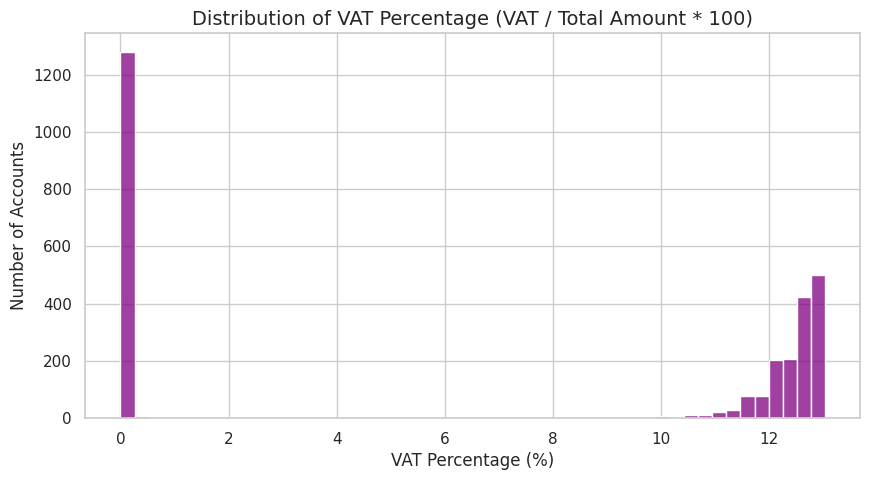

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for accounts with a Total Amount > 0 to avoid division by zero
df_totals = df[df['Numeric Total Amount'] > 0].copy()

# Calculate VAT Percentage
df_totals['VAT_Pct'] = (df_totals['Numeric VAT'] / df_totals['Numeric Total Amount']) * 100

# Round to 2 decimal places to easily group common percentages
df_totals['VAT_Pct'] = df_totals['VAT_Pct'].round(2)

print("--- Top 10 Most Common VAT Percentages ---")
vat_distribution = df_totals['VAT_Pct'].value_counts()
display(vat_distribution.head(10))

# Plot the distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_totals['VAT_Pct'], bins=50, kde=False, color='purple')
plt.title('Distribution of VAT Percentage (VAT / Total Amount * 100)', fontsize=14)
plt.xlabel('VAT Percentage (%)', fontsize=12)
plt.ylabel('Number of Accounts', fontsize=12)
plt.show()

In [28]:
# Identify the baseline (most common VAT percentage > 0)
# We look at VAT > 0 because 0% is common for exempt/0-billed accounts
if len(df_totals[df_totals['VAT_Pct'] > 0]) > 0:
    mode_vat_pct = df_totals[df_totals['VAT_Pct'] > 0]['VAT_Pct'].mode()[0]
    print(f"Detected standard baseline VAT percentage: {mode_vat_pct}%")

    # Define an anomaly as having >0 VAT but not matching the baseline (with a 0.5% tolerance for rounding)
    tolerance = 0.5
    anomaly_mask = (df_totals['VAT_Pct'] > 0) & (abs(df_totals['VAT_Pct'] - mode_vat_pct) > tolerance)
    anomalous_vat_pct_accounts = df_totals[anomaly_mask]

    print(f"\nAccounts with a non-standard VAT percentage (deviating from {mode_vat_pct}% ±{tolerance}%): {len(anomalous_vat_pct_accounts)}")

    if len(anomalous_vat_pct_accounts) > 0:
        columns_to_show = ['Account#', 'Customer', 'Billing Status', 'Numeric VAT', 'Numeric Total Amount', 'VAT_Pct', 'Anomalies']
        display(anomalous_vat_pct_accounts[columns_to_show].sort_values(by='VAT_Pct', ascending=False))
else:
    print("No accounts found with VAT > 0.")

Detected standard baseline VAT percentage: 12.7%

Accounts with a non-standard VAT percentage (deviating from 12.7% ±0.5%): 478


,Account#,Customer,Billing Status,Numeric VAT,Numeric Total Amount,VAT_Pct,Anomalies
2370,500173273,"CAMPBELL, JULIUS",Invoiced,48.74,399.68,12.19,Y
2313,500170048,"SESAY L, AMADU",Invoiced,48.74,399.68,12.19,Y
429,1002923292,UNIVERSAL GAMES,Invoiced,522.54,4286.16,12.19,N
808,500277328,"JALLOH, ASHMAKLU",Invoiced,24.17,198.33,12.19,Y
2129,500616297,"KAMARA, BAI",Invoiced,24.05,197.41,12.18,N
...,...,...,...,...,...,...,...
1261,1002862997,SO PURE 2,Invoiced,0.56,284.31,0.20,N
2189,1002899542,U.M.C. HEALTH AND MATERNITY,Invoiced,0.56,284.31,0.20,N
2815,1002901928,NATIONAL HIV/AID SECRETARIAT,Invoiced,0.98,487.54,0.20,N
76,1002810826,"TARAWALIE, MAMUSU",Invoiced,0.16,381.21,0.04,N


In [29]:
csv_filename_vat = 'anomalous_vat_accounts.csv'

# Save the dataframe of 478 anomalous VAT accounts to a CSV file
anomalous_vat_pct_accounts.to_csv(csv_filename_vat, index=False)
print(f"Successfully saved {len(anomalous_vat_pct_accounts)} records to {csv_filename_vat}.")

# Trigger a download of the file to your local machine
from google.colab import files
files.download(csv_filename_vat)

Successfully saved 478 records to anomalous_vat_accounts.csv.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
print("=========================================================")
print("--- LOGICAL ANOMALY CHECKS FOR TOTAL AMOUNT ---")
print("=========================================================")

# We will use df['Numeric Total Amount'], numeric_consumption, and df['Numeric VAT'] which are already cleaned in memory.

# 1. Total Amount < 0 but Billed Consumption >= 0
mask_neg_total_pos_cons = (df['Numeric Total Amount'] < 0) & (numeric_consumption >= 0)
df_anomaly_1 = df[mask_neg_total_pos_cons]
print(f"\n1. Total Amount < 0 but Billed Consumption >= 0: {len(df_anomaly_1)} accounts")
if len(df_anomaly_1) > 0:
    display(df_anomaly_1[['Account#', 'Customer', 'Numeric Total Amount', 'Billed Consumption', 'Billing Status']].head())

# 2. Total Amount > 0 but Billed Consumption < 0
mask_pos_total_neg_cons = (df['Numeric Total Amount'] > 0) & (numeric_consumption < 0)
df_anomaly_2 = df[mask_pos_total_neg_cons]
print(f"\n2. Total Amount > 0 but Billed Consumption < 0: {len(df_anomaly_2)} accounts")
if len(df_anomaly_2) > 0:
    display(df_anomaly_2[['Account#', 'Customer', 'Numeric Total Amount', 'Billed Consumption', 'Billing Status']].head())

# 3. VAT > Total Amount (Tax cannot be greater than the total bill)
mask_vat_gt_total = df['Numeric VAT'] > df['Numeric Total Amount']
df_anomaly_3 = df[mask_vat_gt_total]
print(f"\n3. VAT > Total Amount: {len(df_anomaly_3)} accounts")
if len(df_anomaly_3) > 0:
    display(df_anomaly_3[['Account#', 'Customer', 'Numeric VAT', 'Numeric Total Amount', 'Billed Consumption']].head())

# 4. Total Amount == 0 but Consumption > 0 (Free Power?)
mask_zero_total_pos_cons = (df['Numeric Total Amount'] == 0) & (numeric_consumption > 0)
df_anomaly_4 = df[mask_zero_total_pos_cons]
print(f"\n4. Total Amount = 0 but Billed Consumption > 0 (Free Power): {len(df_anomaly_4)} accounts")
if len(df_anomaly_4) > 0:
    display(df_anomaly_4[['Account#', 'Customer', 'Numeric Total Amount', 'Billed Consumption', 'Tariff']].head())


--- LOGICAL ANOMALY CHECKS FOR TOTAL AMOUNT ---

1. Total Amount < 0 but Billed Consumption >= 0: 0 accounts

2. Total Amount > 0 but Billed Consumption < 0: 0 accounts

3. VAT > Total Amount: 0 accounts

4. Total Amount = 0 but Billed Consumption > 0 (Free Power): 0 accounts


In [31]:
print("=========================================================")
print("--- DUPLICATE RECORDS ANALYSIS ---")
print("=========================================================")

# 1. Check Account Number duplicates
# For a single monthly billing cycle, each account should ideally appear once.
account_dupes = df[df.duplicated(subset=['Account#'], keep=False)]
print(f"\n1. Duplicated Account Numbers: {len(account_dupes)} rows affected")
if len(account_dupes) > 0:
    display(account_dupes.sort_values(by='Account#')[['Account#', 'Customer', 'Document#', 'Total Amount', 'Billing Status']].head(10))

# 2. Check Invoice Number duplicates (ignoring blanks)
df_valid_invoices = df[df['Invoice#'].astype(str).str.strip() != '']
invoice_dupes = df_valid_invoices[df_valid_invoices.duplicated(subset=['Invoice#'], keep=False)]
print(f"\n2. Duplicated Invoice Numbers: {len(invoice_dupes)} rows affected")
if len(invoice_dupes) > 0:
    display(invoice_dupes.sort_values(by='Invoice#')[['Invoice#', 'Account#', 'Customer', 'Total Amount', 'Billing Status']].head(10))

# 3. Check Bill Number duplicates (ignoring blanks)
df_valid_bills = df[df['Bill #'].astype(str).str.strip() != '']
bill_dupes = df_valid_bills[df_valid_bills.duplicated(subset=['Bill #'], keep=False)]
print(f"\n3. Duplicated Bill Numbers: {len(bill_dupes)} rows affected")
if len(bill_dupes) > 0:
     display(bill_dupes.sort_values(by='Bill #')[['Bill #', 'Account#', 'Customer', 'Total Amount', 'Billing Status']].head(10))

# 4. Check Document Number duplicates (ignoring blanks)
df_valid_docs = df[df['Document#'].astype(str).str.strip() != '']
doc_dupes = df_valid_docs[df_valid_docs.duplicated(subset=['Document#'], keep=False)]
print(f"\n4. Duplicated Document Numbers: {len(doc_dupes)} rows affected")
if len(doc_dupes) > 0:
     display(doc_dupes.sort_values(by='Document#')[['Document#', 'Account#', 'Customer', 'Total Amount', 'Billing Status']].head(10))


--- DUPLICATE RECORDS ANALYSIS ---

1. Duplicated Account Numbers: 0 rows affected

2. Duplicated Invoice Numbers: 0 rows affected

3. Duplicated Bill Numbers: 0 rows affected

4. Duplicated Document Numbers: 59 rows affected


,Document#,Account#,Customer,Total Amount,Billing Status
699,18014312,500306493,"WURIE RAHMAN, ABDUL",13,Invoiced
698,18014312,500306485,"WURIE RAHMAN, ABDUL",13,Invoiced
676,1809257,500274386,"RYAN-COKER, ARNOLD",13,Invoiced
675,1809257,500274360,"RYAN-COKER, ARNOLD",13,Invoiced
1873,18211553,500323472,"KALOKOH A, BENJAMIN",299.33,Invoiced
1874,18211553,500323530,"KALOKOH A, BENJAMIN",13,Invoiced
1875,18213464,500323589,"KAMARA, ABDUL",226.53,Invoiced
1884,18213464,500325139,"KAMARA, ABDUL",134.33,Invoiced
1862,1827317,500322615,"KAMARA B, ABU",299.33,Invoiced
1679,1827317,500257191,"KAMARA B, ABU",182.85,Invoiced


In [32]:
csv_filename_doc_dupes = 'duplicate_document_numbers.csv'

# Save the dataframe of 59 duplicate document records to a CSV file
doc_dupes.to_csv(csv_filename_doc_dupes, index=False)
print(f"Successfully saved {len(doc_dupes)} records to {csv_filename_doc_dupes}.")

# Trigger a download of the file to your local machine
from google.colab import files
files.download(csv_filename_doc_dupes)

Successfully saved 59 records to duplicate_document_numbers.csv.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

--- Summary of Numeric Pending Amount (Debt) ---


,Numeric Pending Amount
count,2.915000e+03
mean,1.892165e+04
std,1.351742e+05
min,0.000000e+00
25%,1.300000e+01
50%,1.780000e+02
75%,7.600000e+02
max,5.021193e+06



Number of accounts with negative Pending Amount (Credits): 0

--- Top 10 Accounts with Highest Pending Amount (Debt) ---


,Account#,Customer,District,Numeric Pending Amount,Collection Status,Anomalies
156,1000038426,LEOCEM -SL LTD,70-FREETOWN CENTRAL,5021192.89,Invoiced,N
415,1000045518,STATE HOUSE,78-FREETOWN CENTRAL,2443506.93,Invoiced,N
2184,1000043331,K.I.T.C,83-FREETOWN EAST,2126282.03,Invoiced,N
2146,500631591,GENERAL BEVERAGES,82-FREETOWN EAST RURAL,1497823.08,Invoiced,N
160,1000039232,BOLLORE,70-FREETOWN CENTRAL,1416824.60,Invoiced,Y
564,1000041160,DATA CENTER,80-FREETOWN WEST,1246152.76,Invoiced,N
164,1000039271,SIERRA LEONE FLOUR MILL LTD,70-FREETOWN CENTRAL,927154.52,Invoiced,Y
2180,1000043281,MILLA GROUP LIMITED,83-FREETOWN EAST,925403.27,Invoiced,Y
2781,1000044016,RADISSON BLU,84-FREETOWN WEST RURAL,905080.96,Invoiced,N
525,1000001891,Q-CELL,80-FREETOWN WEST,861655.74,Invoiced,N


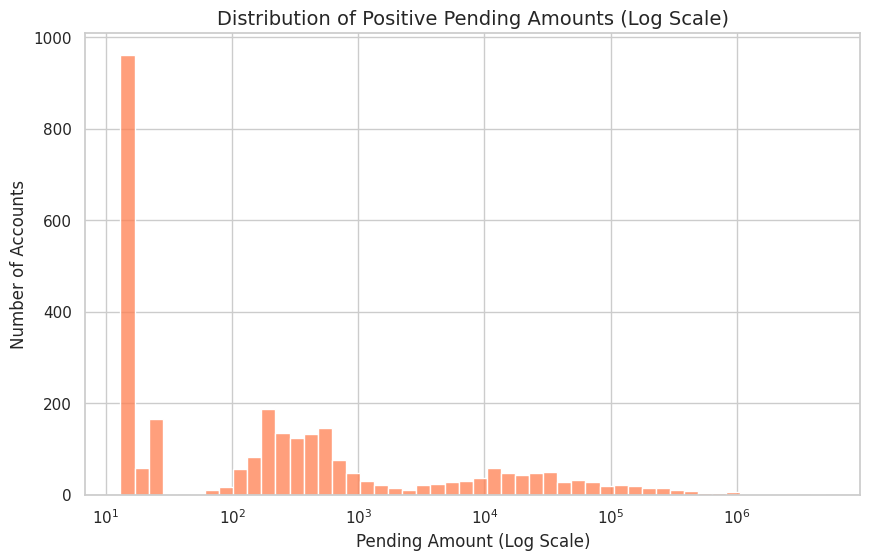

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Summary of Pending Amount
print("--- Summary of Numeric Pending Amount (Debt) ---")
display(df['Numeric Pending Amount'].describe())

# 2. Check for Negative Pending Amounts (Credits)
mask_credits = df['Numeric Pending Amount'] < 0
df_credits = df[mask_credits]
print(f"\nNumber of accounts with negative Pending Amount (Credits): {len(df_credits)}")
if len(df_credits) > 0:
    display(df_credits[['Account#', 'Customer', 'Numeric Pending Amount', 'Billed Consumption', 'Billing Status']].head())

# 3. Top 10 Accounts with Highest Debt
print("\n--- Top 10 Accounts with Highest Pending Amount (Debt) ---")
top_debtors = df.nlargest(10, 'Numeric Pending Amount')
display(top_debtors[['Account#', 'Customer', 'District', 'Numeric Pending Amount', 'Collection Status', 'Anomalies']])

# 4. Visualization of Pending Amount Distribution (Log Scale)
plt.figure(figsize=(10, 6))
# Filter for Debt > 0 for log-scale plotting
positive_debt = df[df['Numeric Pending Amount'] > 0]['Numeric Pending Amount']

if len(positive_debt) > 0:
    # We use a log scale because financial debt distributions are often heavily skewed
    sns.histplot(positive_debt, bins=50, kde=False, color='coral', log_scale=True)
    plt.title('Distribution of Positive Pending Amounts (Log Scale)', fontsize=14)
    plt.xlabel('Pending Amount (Log Scale)', fontsize=12)
    plt.ylabel('Number of Accounts', fontsize=12)
    plt.show()
else:
    print("\nNo accounts with a positive Pending Amount to plot.")


In [34]:
import pandas as pd

# 1. Distribution of Tariffs
print("--- Distribution of Accounts by Tariff ---")
display(df['Tariff'].value_counts(dropna=False))

# Prepare a temporary dataframe with numeric values for accurate aggregation
temp_tariff_df = df[['Account#', 'Customer', 'Tariff', 'Service', 'Billing Type', 'Anomalies']].copy()
temp_tariff_df['Numeric Consumption'] = numeric_consumption
temp_tariff_df['Numeric Total Amount'] = df['Numeric Total Amount']

# 2. Key Metrics Aggregated by Tariff
print("\n--- Summary of Billed Consumption by Tariff ---")
display(temp_tariff_df.groupby('Tariff')['Numeric Consumption'].describe().round(2))

print("\n--- Summary of Total Amount Billed by Tariff ---")
display(temp_tariff_df.groupby('Tariff')['Numeric Total Amount'].describe().round(2))

# 3. Check for Blank/Missing Tariffs
blank_tariff_mask = df['Tariff'].astype(str).str.strip() == ''
blank_tariffs = df[blank_tariff_mask]

print(f"\n--- Accounts with Blank/Missing Tariff: {len(blank_tariffs)} ---")
if len(blank_tariffs) > 0:
    display(blank_tariffs[['Account#', 'Customer', 'Billed Consumption', 'Total Amount', 'Billing Status', 'Service']].head(10))


--- Distribution of Accounts by Tariff ---


,count
Tariff,
T1-Residential - Postpayment,2070
T4-MDI – Postpayment-Monthly,729
T2-Commercial – Postpayment,57
T3-Institutions – Postpayment,35
T4-MDI-Postpayment-Biweekly,23
T7-Welders – Postpayment,1



--- Summary of Billed Consumption by Tariff ---


,count,mean,std,min,25%,50%,75%,max
Tariff,,,,,,,,
T1-Residential - Postpayment,2070.0,110.19,2899.35,0.00,0.00,0.00,47.00,131203.00
T2-Commercial – Postpayment,57.0,327.70,1108.41,0.00,0.00,0.00,60.00,5901.54
T3-Institutions – Postpayment,35.0,2600.17,12566.80,0.00,0.00,0.00,51.00,73750.00
T4-MDI – Postpayment-Monthly,729.0,11029.85,38878.93,0.00,608.44,2296.98,6927.92,745305.00
T4-MDI-Postpayment-Biweekly,23.0,5410.80,7152.25,0.00,231.38,3296.96,7698.62,27416.00
T7-Welders – Postpayment,1.0,76.48,NaN,76.48,76.48,76.48,76.48,76.48



--- Summary of Total Amount Billed by Tariff ---


,count,mean,std,min,25%,50%,75%,max
Tariff,,,,,,,,
T1-Residential - Postpayment,2070.0,576.71,15264.17,13.00,13.00,26.00,244.39,691495.30
T2-Commercial – Postpayment,57.0,2100.53,7024.51,18.00,18.00,18.00,398.26,37419.90
T3-Institutions – Postpayment,35.0,15882.01,76666.84,18.00,18.00,18.00,329.14,449948.30
T4-MDI – Postpayment-Monthly,729.0,74559.99,261860.64,80.00,4406.50,15714.74,46935.39,5021192.89
T4-MDI-Postpayment-Biweekly,23.0,36994.31,48183.40,123.00,2157.70,22540.41,51927.59,185410.32
T7-Welders – Postpayment,1.0,481.33,NaN,481.33,481.33,481.33,481.33,481.33



--- Accounts with Blank/Missing Tariff: 0 ---


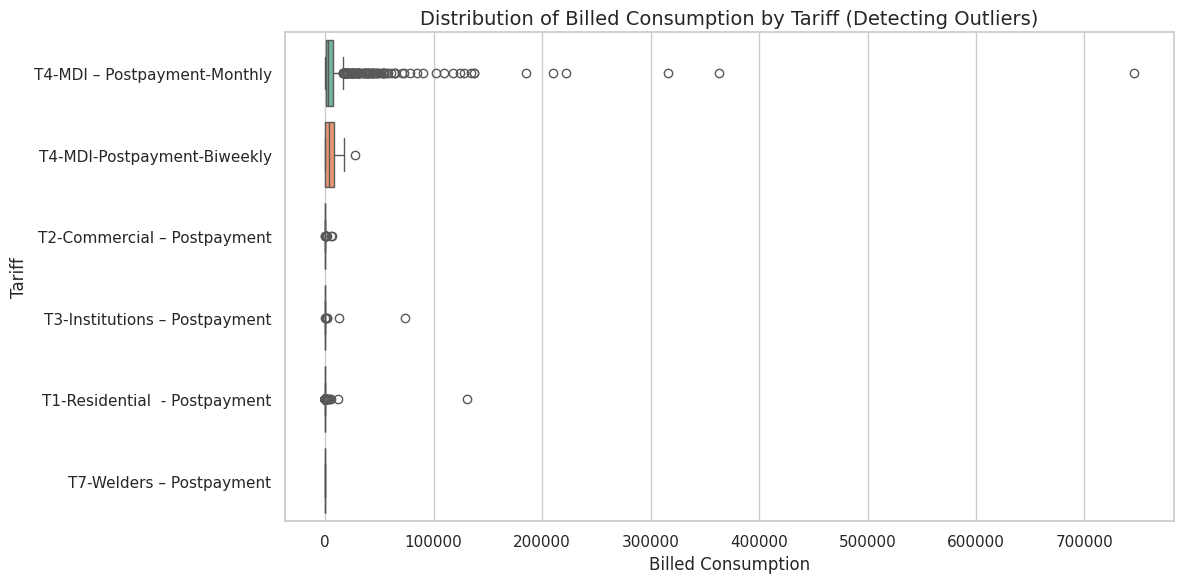

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Visualizing Consumption Outliers by Tariff
plt.figure(figsize=(12, 6))

# We use a boxplot to easily spot extreme outliers in consumption for each tariff group
# Fixed the warning by adding hue='Tariff' and legend=False
sns.boxplot(data=temp_tariff_df, y='Tariff', x='Numeric Consumption', hue='Tariff', palette='Set2', legend=False)

plt.title('Distribution of Billed Consumption by Tariff (Detecting Outliers)', fontsize=14)
plt.xlabel('Billed Consumption', fontsize=12)
plt.ylabel('Tariff', fontsize=12)

# Add a log scale if the data is too skewed, but let's try linear first to see raw outliers
# plt.xscale('log')

plt.tight_layout()
plt.show()


In [37]:
# 1. Investigate the extreme outlier in T1-Residential
print("--- Investigating Extreme Outlier in T1-Residential ---")
t1_mask = df['Tariff'] == 'T1-Residential  - Postpayment'
outlier_t1 = df[t1_mask & (numeric_consumption > 100000)]
if len(outlier_t1) > 0:
    columns_outlier = ['Account#', 'Customer', 'Tariff', 'Service', 'Billing Type', 'Billed Consumption', 'Total Amount', 'Anomalies']
    display(outlier_t1[columns_outlier])
else:
    print("No extreme outlier > 100,000 found in T1-Residential.")

# 2. Analyze 'Service' field
print("\n--- Distribution of Service Types ---")
display(df['Service'].value_counts(dropna=False))

# 3. Cross-tabulation: Service vs Tariff
print("\n--- Cross-tabulation: Service vs Tariff ---")
crosstab_service_tariff = pd.crosstab(df['Service'], df['Tariff'])
display(crosstab_service_tariff)

# 4. Analyze 'Billing Type' field
print("\n--- Distribution of Billing Types ---")
display(df['Billing Type'].value_counts(dropna=False))


--- Investigating Extreme Outlier in T1-Residential ---


,Account#,Customer,Tariff,Service,Billing Type,Billed Consumption,Total Amount,Anomalies
2018,500371505,"VALICIOUS, FINELY",T1-Residential - Postpayment,Electricity Postpaid,In cycle,131 203.00,691 495.30,N



--- Distribution of Service Types ---


,count
Service,
Electricity Postpaid,2915



--- Cross-tabulation: Service vs Tariff ---


Tariff,T1-Residential - Postpayment,T2-Commercial – Postpayment,T3-Institutions – Postpayment,T4-MDI – Postpayment-Monthly,T4-MDI-Postpayment-Biweekly,T7-Welders – Postpayment
Service,,,,,,
Electricity Postpaid,2070,57,35,729,23,1



--- Distribution of Billing Types ---


,count
Billing Type,
In cycle,2915


In [38]:
csv_filename_debt = 'pending_amount_debtors.csv'

# Filter accounts with debt > 0 and sort descending
debtors_df = df[df['Numeric Pending Amount'] > 0].sort_values(by='Numeric Pending Amount', ascending=False)

# Select relevant columns for the export
columns_to_export = ['Account#', 'Customer', 'District', 'Tariff', 'Billing Status', 'Collection Status', 'Anomalies', 'Numeric Pending Amount']
debtors_export = debtors_df[columns_to_export]

# Save to CSV
debtors_export.to_csv(csv_filename_debt, index=False)
print(f"Successfully saved {len(debtors_export)} records to {csv_filename_debt}.")

# Trigger download
from google.colab import files
files.download(csv_filename_debt)


Successfully saved 2861 records to pending_amount_debtors.csv.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
import pandas as pd
import numpy as np

# 1. Create a clean dataframe for rate analysis
df_rates = pd.DataFrame({
    'Account#': df['Account#'],
    'Customer': df['Customer'],
    'Tariff': df['Tariff'],
    'Consumption': numeric_consumption,
    'Total_Amount': df['Numeric Total Amount'],
    'VAT': df['Numeric VAT'],
    'Anomalies': df['Anomalies'].astype(str).str.strip().str.upper()
})

# Filter out 0 consumption to avoid division by zero
df_rates_valid = df_rates[df_rates['Consumption'] > 0].copy()

# Calculate Base Amount (Total Amount excluding Tax/VAT)
df_rates_valid['Base_Amount'] = df_rates_valid['Total_Amount'] - df_rates_valid['VAT']

# Calculate Effective Rate per unit
df_rates_valid['Effective_Rate'] = df_rates_valid['Base_Amount'] / df_rates_valid['Consumption']

print("--- Summary of Effective Billing Rate (Per Unit) by Tariff ---")
print("(Excludes exactly 0 consumption accounts)")
display(df_rates_valid.groupby('Tariff')['Effective_Rate'].describe().round(2))

# 2. Distribution of Anomalies Flag by Tariff (using the full dataset)
print("\n--- Anomalies ('Y') Flag Distribution by Tariff ---")
tariff_anomalies = pd.crosstab(df['Tariff'], df['Anomalies'].astype(str).str.strip().str.upper())

# Safely calculate percentage if both 'Y' and 'N' exist
if 'Y' in tariff_anomalies.columns and 'N' in tariff_anomalies.columns:
    tariff_anomalies['% Anomalous (Y)'] = (tariff_anomalies['Y'] / (tariff_anomalies['Y'] + tariff_anomalies['N']) * 100).round(2)

display(tariff_anomalies)


--- Summary of Effective Billing Rate (Per Unit) by Tariff ---
(Excludes exactly 0 consumption accounts)


,count,mean,std,min,25%,50%,75%,max
Tariff,,,,,,,,
T1-Residential - Postpayment,923.0,4.54,0.49,3.31,4.35,4.46,4.61,17.22
T2-Commercial – Postpayment,23.0,7.28,7.17,5.51,5.54,5.81,5.89,40.13
T3-Institutions – Postpayment,12.0,5.50,0.20,5.31,5.33,5.44,5.64,5.89
T4-MDI – Postpayment-Monthly,669.0,25.40,260.66,5.86,5.89,5.97,6.18,6339.17
T4-MDI-Postpayment-Biweekly,20.0,9.50,10.77,5.87,5.90,5.99,6.51,52.30
T7-Welders – Postpayment,1.0,5.55,NaN,5.55,5.55,5.55,5.55,5.55



--- Anomalies ('Y') Flag Distribution by Tariff ---


Anomalies,N,Y,% Anomalous (Y)
Tariff,,,
T1-Residential - Postpayment,1286,784,37.87
T2-Commercial – Postpayment,43,14,24.56
T3-Institutions – Postpayment,27,8,22.86
T4-MDI – Postpayment-Monthly,634,95,13.03
T4-MDI-Postpayment-Biweekly,20,3,13.04
T7-Welders – Postpayment,1,0,0.00


In [40]:
import pandas as pd

# 1. Calculate the Interquartile Range (IQR) to find extreme outliers
Q1 = df_rates_valid['Effective_Rate'].quantile(0.25)
Q3 = df_rates_valid['Effective_Rate'].quantile(0.75)
IQR = Q3 - Q1

# Define 'hyper-inflated' as an extreme outlier (Q3 + 3 * IQR)
extreme_threshold = Q3 + 3 * IQR
print(f"Defining hyper-inflated rates as those > {extreme_threshold:.2f} (Extreme Outlier Threshold)\n")

# 2. Filter the dataframe for these extreme rates and sort them descending
anomalous_rates_df = df_rates_valid[df_rates_valid['Effective_Rate'] > extreme_threshold].sort_values(by='Effective_Rate', ascending=False)

print(f"Found {len(anomalous_rates_df)} accounts with hyper-inflated billing rates.\n")

if len(anomalous_rates_df) > 0:
    # Display top 10 worst offenders
    print("--- Top 10 Accounts with Highest Effective Rates ---")
    display(anomalous_rates_df.head(10))


Defining hyper-inflated rates as those > 10.49 (Extreme Outlier Threshold)

Found 47 accounts with hyper-inflated billing rates.

--- Top 10 Accounts with Highest Effective Rates ---


,Account#,Customer,Tariff,Consumption,Total_Amount,VAT,Anomalies,Base_Amount,Effective_Rate
95,1002920217,NEW MANUFACTURING INDUSTRY EDSA98040002374,T4-MDI – Postpayment-Monthly,0.06,380.40,0.05,N,380.35,6339.166667
76,1002810826,"TARAWALIE, MAMUSU",T4-MDI – Postpayment-Monthly,0.18,381.21,0.16,N,381.05,2116.944444
2189,1002899542,U.M.C. HEALTH AND MATERNITY,T4-MDI – Postpayment-Monthly,0.64,284.31,0.56,N,283.75,443.359375
1261,1002862997,SO PURE 2,T4-MDI – Postpayment-Monthly,0.64,284.31,0.56,N,283.75,443.359375
2815,1002901928,NATIONAL HIV/AID SECRETARIAT,T4-MDI – Postpayment-Monthly,1.12,487.54,0.98,N,486.56,434.428571
2858,1002972893,CENTRAL PUBLIC,T4-MDI – Postpayment-Monthly,0.96,286.46,0.84,N,285.62,297.520833
727,1000001958,U.N.D.P,T4-MDI – Postpayment-Monthly,0.64,153.89,0.56,N,153.33,239.578125
585,1002734487,UMC SURGICAL,T4-MDI – Postpayment-Monthly,1.36,289.15,1.19,N,287.96,211.735294
286,1002792705,NP SL LTD (T4),T4-MDI – Postpayment-Monthly,1.36,289.15,1.19,Y,287.96,211.735294
434,1002923391,FIRST INTERNATIONAL BANK,T4-MDI – Postpayment-Monthly,1.92,392.93,1.69,Y,391.24,203.770833


In [41]:
csv_filename_rates = 'hyper_inflated_billing_rates.csv'

# 3. Save the anomalous rates dataframe to a CSV file
anomalous_rates_df.to_csv(csv_filename_rates, index=False)
print(f"Successfully saved {len(anomalous_rates_df)} records to {csv_filename_rates}.")

# 4. Trigger a download of the file to your local machine
from google.colab import files
files.download(csv_filename_rates)


Successfully saved 47 records to hyper_inflated_billing_rates.csv.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
# 1. Clean the Anomalies column to ensure consistent grouping (remove spaces, make uppercase)
df['Clean_Anomalies'] = df['Anomalies'].astype(str).str.strip().str.upper()

print("--- Overall Distribution of Official 'Anomalies' Flag ---")
overall_anomalies = df['Clean_Anomalies'].value_counts(dropna=False)
display(overall_anomalies)

print(f"\nPercentage of accounts flagged with an anomaly: {(overall_anomalies.get('Y', 0) / len(df) * 100):.2f}%")


--- Overall Distribution of Official 'Anomalies' Flag ---


,count
Clean_Anomalies,
N,2011
Y,904



Percentage of accounts flagged with an anomaly: 31.01%


--- Top 10 Districts with the Highest NUMBER of Anomalous Accounts ---


Clean_Anomalies,N,Y,Total_Accounts,% Anomalous (Y)
District,,,,
82-FREETOWN EAST RURAL,804,539,1343,40.13
83-FREETOWN EAST,407,175,582,30.07
84-FREETOWN WEST RURAL,136,30,166,18.07
80-FREETOWN WEST,175,28,203,13.79
75-FREETOWN CENTRAL,25,23,48,47.92
81-FREETOWN WEST,77,23,100,23.00
72-FREETOWN CENTRAL,26,16,42,38.10
41-KENEMA,24,10,34,29.41
51-BOMBALI,37,9,46,19.57


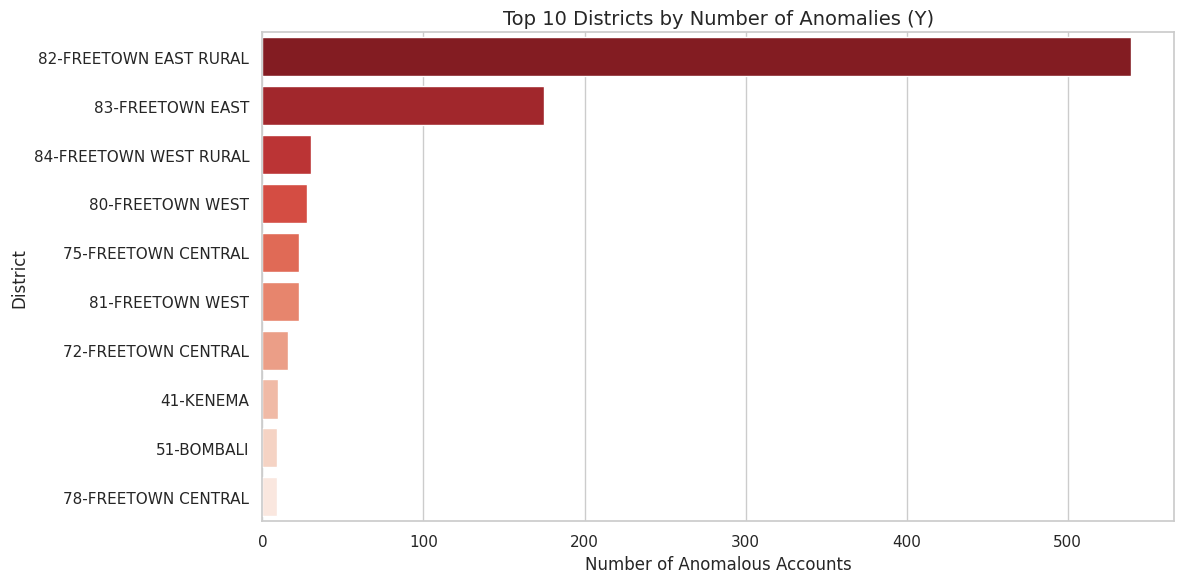

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Analyze Anomalies by District
district_anomalies = pd.crosstab(df['District'], df['Clean_Anomalies'])

# Calculate percentages if both Y and N exist
if 'Y' in district_anomalies.columns and 'N' in district_anomalies.columns:
    district_anomalies['Total_Accounts'] = district_anomalies['Y'] + district_anomalies['N']
    district_anomalies['% Anomalous (Y)'] = (district_anomalies['Y'] / district_anomalies['Total_Accounts'] * 100).round(2)

    # Sort by the highest number of anomalies
    district_anomalies_sorted = district_anomalies.sort_values(by='Y', ascending=False)

    print("--- Top 10 Districts with the Highest NUMBER of Anomalous Accounts ---")
    display(district_anomalies_sorted.head(10))

    # Plotting
    plt.figure(figsize=(12, 6))
    sns.barplot(data=district_anomalies_sorted.head(10).reset_index(), x='Y', y='District', palette='Reds_r', hue='District', legend=False)
    plt.title('Top 10 Districts by Number of Anomalies (Y)', fontsize=14)
    plt.xlabel('Number of Anomalous Accounts', fontsize=12)
    plt.ylabel('District', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    display(district_anomalies)


In [44]:
# 3. Analyze the Financial Impact of Anomalous Accounts
print("--- Total Financial Value by Anomaly Flag ---")
impact_df = df.groupby('Clean_Anomalies')[['Numeric Total Amount', 'Numeric Pending Amount']].sum().round(2)
display(impact_df)

print("\n--- Average Debt (Pending Amount) per Account ---")
avg_debt_df = df.groupby('Clean_Anomalies')['Numeric Pending Amount'].mean().round(2).reset_index()
avg_debt_df.rename(columns={'Numeric Pending Amount': 'Avg_Pending_Amount_Per_Account'}, inplace=True)
display(avg_debt_df)


--- Total Financial Value by Anomaly Flag ---


,Numeric Total Amount,Numeric Pending Amount
Clean_Anomalies,,
N,48498826.93,46694833.82
Y,8576143.65,8461789.12



--- Average Debt (Pending Amount) per Account ---


,Clean_Anomalies,Avg_Pending_Amount_Per_Account
0,N,23219.71
1,Y,9360.39


In [45]:
csv_filename_anomalies = 'official_anomalous_accounts.csv'

# Filter the dataframe for officially flagged anomalous accounts
anomalous_accounts_df = df[df['Clean_Anomalies'] == 'Y'].copy()

# Save the dataframe to a CSV file
anomalous_accounts_df.to_csv(csv_filename_anomalies, index=False)
print(f"Successfully saved {len(anomalous_accounts_df)} records to {csv_filename_anomalies}.")

# Trigger a download of the file to your local machine
from google.colab import files
files.download(csv_filename_anomalies)


Successfully saved 904 records to official_anomalous_accounts.csv.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
import numpy as np

# 1. Initialize the Master Composite DataFrame
df_composite = pd.DataFrame({
    'Account#': df['Account#'],
    'Customer': df['Customer'],
    'District': df['District'],
    'Tariff': df['Tariff'],
    'Billed Consumption': numeric_consumption,
    'Pending Amount (Debt)': df['Numeric Pending Amount']
})

# 2. Re-create the masks for each anomaly logic

# A. Official Anomaly 'Y'
flag_official = (df['Clean_Anomalies'] == 'Y').astype(int)

# B. Pending Termination with > 0 Consumption
term_mask = df['Contracted Service Status'].astype(str).str.contains('pending term|terminat', case=False, na=False)
flag_pending_term = (term_mask & (numeric_consumption > 0)).astype(int)

# C. 'Generated' Status with > 0 Consumption
flag_generated = ((df['Billing Status'] == 'Generated') & (numeric_consumption > 0)).astype(int)

# D. Blank Collection Status
flag_blank_col = (df['Collection Status'].astype(str).str.strip() == '').astype(int)

# E. Anomalous VAT Percentage (Deviating from 12.7% baseline)
# Avoid division by zero
safe_total = df['Numeric Total Amount'].replace(0, np.nan)
vat_pct = (df['Numeric VAT'] / safe_total) * 100
flag_vat = ((vat_pct > 0) & (abs(vat_pct - 12.7) > 0.5)).astype(int)

# F. Hyper-Inflated Effective Rate (> 10.49)
safe_cons = numeric_consumption.replace(0, np.nan)
eff_rate = (df['Numeric Total Amount'] - df['Numeric VAT']) / safe_cons
flag_rate = ((numeric_consumption > 0) & (eff_rate > 10.49)).astype(int)

# 3. Add flags to the composite dataframe
df_composite['Flag_Official_Y'] = flag_official
df_composite['Flag_PendingTerm_Cons'] = flag_pending_term
df_composite['Flag_Generated_Cons'] = flag_generated
df_composite['Flag_Blank_Collection'] = flag_blank_col
df_composite['Flag_Anomalous_VAT'] = flag_vat
df_composite['Flag_HyperInflated_Rate'] = flag_rate

# 4. Calculate Total Score and Prioritization
# Sum of all anomaly flags
df_composite['Total_Anomaly_Score'] = (
    df_composite['Flag_Official_Y'] +
    df_composite['Flag_PendingTerm_Cons'] +
    df_composite['Flag_Generated_Cons'] +
    df_composite['Flag_Blank_Collection'] +
    df_composite['Flag_Anomalous_VAT'] +
    df_composite['Flag_HyperInflated_Rate']
)

# Define Priority Categories
def assign_priority(score):
    if score >= 3:
        return '1 - CRITICAL (3+ Anomalies)'
    elif score == 2:
        return '2 - HIGH (2 Anomalies)'
    elif score == 1:
        return '3 - MEDIUM (1 Anomaly)'
    else:
        return '4 - LOW/NONE (0 Anomalies)'

df_composite['Priority_Category'] = df_composite['Total_Anomaly_Score'].apply(assign_priority)

print("Composite analysis complete. Master table created.")


Composite analysis complete. Master table created.


--- Accounts by Priority Category ---


,count
Priority_Category,
1 - CRITICAL (3+ Anomalies),12
2 - HIGH (2 Anomalies),288
3 - MEDIUM (1 Anomaly),942
4 - LOW/NONE (0 Anomalies),1673


/tmp/ipykernel_705/310517152.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_composite, x='Total_Anomaly_Score', palette='Reds')


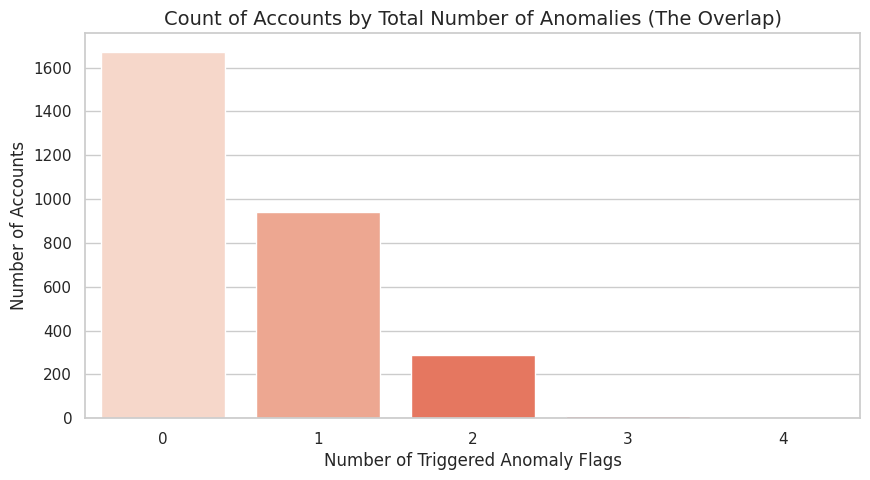


Found 300 accounts with MULTIPLE (2+) intersecting anomalies:


,Account#,Customer,District,Tariff,Billed Consumption,Pending Amount (Debt),Flag_Official_Y,Flag_PendingTerm_Cons,Flag_Generated_Cons,Flag_Blank_Collection,Flag_Anomalous_VAT,Flag_HyperInflated_Rate,Total_Anomaly_Score,Priority_Category
717,500547928,NATCA,80-FREETOWN WEST,T4-MDI – Postpayment-Monthly,27.20,1263.17,1,1,0,0,1,1,4,1 - CRITICAL (3+ Anomalies)
434,1002923391,FIRST INTERNATIONAL BANK,78-FREETOWN CENTRAL,T4-MDI – Postpayment-Monthly,1.92,392.93,1,0,0,0,1,1,3,1 - CRITICAL (3+ Anomalies)
325,500607524,GUMA VALLEY WATER COMPANY,75-FREETOWN CENTRAL,T4-MDI – Postpayment-Monthly,55.00,750.39,1,0,0,0,1,1,3,1 - CRITICAL (3+ Anomalies)
286,1002792705,NP SL LTD (T4),75-FREETOWN CENTRAL,T4-MDI – Postpayment-Monthly,1.36,289.15,1,0,0,0,1,1,3,1 - CRITICAL (3+ Anomalies)
2612,500305206,"SESAY, FATMATA",83-FREETOWN EAST,T1-Residential - Postpayment,31.00,163.44,0,0,1,1,1,0,3,1 - CRITICAL (3+ Anomalies)
2589,500260286,"KING NATHANIEL, CLAUDIUS",83-FREETOWN EAST,T1-Residential - Postpayment,24.00,129.47,0,0,1,1,1,0,3,1 - CRITICAL (3+ Anomalies)
2462,500177932,"KAMARA, KADIE",83-FREETOWN EAST,T1-Residential - Postpayment,35.00,182.85,0,0,1,1,1,0,3,1 - CRITICAL (3+ Anomalies)
2201,1002952715,ABDUL BANGURA,83-FREETOWN EAST,T4-MDI – Postpayment-Monthly,14.88,480.21,0,1,0,0,1,1,3,1 - CRITICAL (3+ Anomalies)
504,1002956843,"DAVIES, CHRISTAIN",79-FREETOWN CENTRAL,T4-MDI – Postpayment-Monthly,69.06,845.08,1,0,0,0,1,1,3,1 - CRITICAL (3+ Anomalies)
39,1002922252,DIAMOND LODGE HOTEL EDSA24230002768,48-KONO,T4-MDI – Postpayment-Monthly,19.98,514.55,1,0,0,0,1,1,3,1 - CRITICAL (3+ Anomalies)


In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Summary of Prioritization Categories
print("--- Accounts by Priority Category ---")
priority_counts = df_composite['Priority_Category'].value_counts().sort_index()
display(priority_counts)

# 2. Visualize the overlap distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df_composite, x='Total_Anomaly_Score', palette='Reds')
plt.title('Count of Accounts by Total Number of Anomalies (The Overlap)', fontsize=14)
plt.xlabel('Number of Triggered Anomaly Flags', fontsize=12)
plt.ylabel('Number of Accounts', fontsize=12)
plt.show()

# 3. Show the highly critical accounts (Score >= 2)
critical_accounts = df_composite[df_composite['Total_Anomaly_Score'] >= 2].sort_values(by='Total_Anomaly_Score', ascending=False)
print(f"\nFound {len(critical_accounts)} accounts with MULTIPLE (2+) intersecting anomalies:")
if len(critical_accounts) > 0:
    display(critical_accounts.head(15))


In [48]:
csv_filename_composite = 'composite_anomaly_prioritization.csv'

# Sort the dataframe so the highest priority accounts are at the top
df_composite_sorted = df_composite.sort_values(by=['Total_Anomaly_Score', 'Pending Amount (Debt)'], ascending=[False, False])

# Save the dataframe to a CSV file
df_composite_sorted.to_csv(csv_filename_composite, index=False)
print(f"Successfully saved {len(df_composite_sorted)} prioritized records to {csv_filename_composite}.")

# Trigger a download of the file to your local machine
from google.colab import files
files.download(csv_filename_composite)


Successfully saved 2915 prioritized records to composite_anomaly_prioritization.csv.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
import numpy as np

# 1. Define Weights for each anomaly type
weights = {
    'Flag_PendingTerm_Cons': 5,      # Critical: Consuming power but slated for termination
    'Flag_Generated_Cons': 4,        # High: Consuming power but bill not issued
    'Flag_HyperInflated_Rate': 3,    # High: Pricing error/system glitch
    'Flag_Anomalous_VAT': 2,         # Medium: Tax compliance risk
    'Flag_Official_Y': 1,            # Low: General system flag
    'Flag_Blank_Collection': 1       # Low: Data entry missing
}

# Calculate the Weighted Anomaly Score
df_composite['Weighted_Anomaly_Score'] = (
    (df_composite['Flag_PendingTerm_Cons'] * weights['Flag_PendingTerm_Cons']) +
    (df_composite['Flag_Generated_Cons'] * weights['Flag_Generated_Cons']) +
    (df_composite['Flag_HyperInflated_Rate'] * weights['Flag_HyperInflated_Rate']) +
    (df_composite['Flag_Anomalous_VAT'] * weights['Flag_Anomalous_VAT']) +
    (df_composite['Flag_Official_Y'] * weights['Flag_Official_Y']) +
    (df_composite['Flag_Blank_Collection'] * weights['Flag_Blank_Collection'])
)

# 2. Define Financial Exposure (Debt) Multiplier (1 to 5)
def get_debt_multiplier(debt):
    if debt <= 0:
        return 1       # No debt
    elif debt < 5000:
        return 2       # Low debt
    elif debt < 25000:
        return 3       # Medium debt
    elif debt < 100000:
        return 4       # High debt
    else:
        return 5       # Extreme debt (>= 100,000)

df_composite['Debt_Multiplier'] = df_composite['Pending Amount (Debt)'].apply(get_debt_multiplier)

# 3. Calculate Final Risk Score (0 to 100 scale approximately)
# Max possible anomaly weight = 16. Max debt multiplier = 5. Max raw score = 80.
# We will scale it so it looks like a standard 0-100 risk score.
df_composite['Raw_Risk_Score'] = df_composite['Weighted_Anomaly_Score'] * df_composite['Debt_Multiplier']
max_raw = df_composite['Raw_Risk_Score'].max() if df_composite['Raw_Risk_Score'].max() > 0 else 1
df_composite['Final_Risk_Score_100'] = ((df_composite['Raw_Risk_Score'] / max_raw) * 100).round(1)

# 4. Assign Risk Tiers
def assign_risk_tier(score):
    if score >= 75:
        return 'CRITICAL RISK'
    elif score >= 50:
        return 'HIGH RISK'
    elif score >= 25:
        return 'MEDIUM RISK'
    elif score > 0:
        return 'LOW RISK'
    else:
        return 'NO RISK'

df_composite['Risk_Tier'] = df_composite['Final_Risk_Score_100'].apply(assign_risk_tier)

print("Risk scoring complete. Weighted Risk Scores and Tiers have been assigned.")


Risk scoring complete. Weighted Risk Scores and Tiers have been assigned.


In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Summary of Risk Tiers
print("--- Accounts by Final Risk Tier ---")
risk_counts = df_composite['Risk_Tier'].value_counts()
display(risk_counts)

# 2. Show the top highest-risk accounts
top_risks = df_composite.sort_values(by='Final_Risk_Score_100', ascending=False)
print("\n--- Top 15 Highest Risk Accounts ---")
columns_to_show = ['Account#', 'Customer', 'Pending Amount (Debt)', 'Weighted_Anomaly_Score', 'Debt_Multiplier', 'Final_Risk_Score_100', 'Risk_Tier']
display(top_risks[columns_to_show].head(15))


--- Accounts by Final Risk Tier ---


,count
Risk_Tier,
NO RISK,1673
LOW RISK,935
MEDIUM RISK,289
HIGH RISK,15
CRITICAL RISK,3



--- Top 15 Highest Risk Accounts ---


,Account#,Customer,Pending Amount (Debt),Weighted_Anomaly_Score,Debt_Multiplier,Final_Risk_Score_100,Risk_Tier
717,500547928,NATCA,1263.17,11,2,100.0,CRITICAL RISK
2201,1002952715,ABDUL BANGURA,480.21,10,2,90.9,CRITICAL RISK
1,1000037628,THE MANAGER BSL,33534.84,5,4,90.9,CRITICAL RISK
2612,500305206,"SESAY, FATMATA",163.44,7,2,63.6,HIGH RISK
2589,500260286,"KING NATHANIEL, CLAUDIUS",129.47,7,2,63.6,HIGH RISK
2462,500177932,"KAMARA, KADIE",182.85,7,2,63.6,HIGH RISK
44,1000038372,ST. JOHN OF GOD CATHOLIC HOSPITAL,1041.92,6,2,54.5,HIGH RISK
43,1000035881,HEALTH CENTRE COMMUNITY,503.85,6,2,54.5,HIGH RISK
1924,500333992,"BANGURA, KADIATU",503.15,6,2,54.5,HIGH RISK
504,1002956843,"DAVIES, CHRISTAIN",845.08,6,2,54.5,HIGH RISK


In [51]:
csv_filename_risk = 'weighted_risk_scores.csv'

# Save the sorted dataframe to a CSV file
top_risks.to_csv(csv_filename_risk, index=False)
print(f"Successfully saved {len(top_risks)} risk-scored records to {csv_filename_risk}.")

# Trigger a download
from google.colab import files
files.download(csv_filename_risk)


Successfully saved 2915 risk-scored records to weighted_risk_scores.csv.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Executive Summary Dashboard
Using `plotly` and `ipywidgets` to create an interactive dashboard of our findings.

In [52]:
import plotly.express as px
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

# 1. Risk Tier Distribution (Donut Chart)
risk_counts_df = df_composite['Risk_Tier'].value_counts().reset_index()
risk_counts_df.columns = ['Risk_Tier', 'Count']

fig_risk = px.pie(risk_counts_df, values='Count', names='Risk_Tier',
                  title='Distribution of Accounts by Risk Tier',
                  hole=0.4, color='Risk_Tier',
                  color_discrete_map={'CRITICAL RISK':'darkred', 'HIGH RISK':'red',
                                      'MEDIUM RISK':'orange', 'LOW RISK':'gold', 'NO RISK':'green'})
fig_risk.update_layout(margin=dict(t=40, b=0, l=0, r=0))

# 2. Debt Exposure by District for At-Risk Accounts (Medium, High, Critical)
at_risk_df = df_composite[df_composite['Risk_Tier'].isin(['CRITICAL RISK', 'HIGH RISK', 'MEDIUM RISK'])]
debt_by_district = at_risk_df.groupby('District')['Pending Amount (Debt)'].sum().reset_index()
debt_by_district = debt_by_district.sort_values('Pending Amount (Debt)', ascending=False).head(10)

fig_debt = px.bar(debt_by_district, x='Pending Amount (Debt)', y='District', orientation='h',
                  title='Top 10 Districts by Debt (At-Risk Accounts Only)',
                  color='Pending Amount (Debt)', color_continuous_scale='Reds')
fig_debt.update_layout(yaxis={'categoryorder':'total ascending'}, margin=dict(t=40, b=0, l=0, r=0))

# 3. Anomaly Overlap Counts
anomaly_overlap = df_composite['Total_Anomaly_Score'].value_counts().reset_index()
anomaly_overlap.columns = ['Total_Anomalies', 'Count']
fig_overlap = px.bar(anomaly_overlap, x='Total_Anomalies', y='Count',
                     title='Count of Accounts by Total Anomalies',
                     labels={'Total_Anomalies': 'Number of Triggered Anomalies', 'Count': 'Number of Accounts'})
fig_overlap.update_layout(xaxis=dict(tickmode='linear'), margin=dict(t=40, b=0, l=0, r=0))

# 4. Scatter Plot: Debt vs Consumption colored by Risk
fig_scatter = px.scatter(df_composite, x='Billed Consumption', y='Pending Amount (Debt)',
                         color='Risk_Tier', hover_data=['Account#', 'Customer', 'District'],
                         title='Debt vs. Billed Consumption',
                         color_discrete_map={'CRITICAL RISK':'darkred', 'HIGH RISK':'red',
                                             'MEDIUM RISK':'orange', 'LOW RISK':'gold', 'NO RISK':'green'})
fig_scatter.update_layout(margin=dict(t=40, b=0, l=0, r=0))

print("Charts generated successfully. Rendering dashboard layout next...")

Charts generated successfully. Rendering dashboard layout next...


In [54]:
# 5. Display the interactive dashboard sequentially
from IPython.display import display, HTML

display(HTML("<h2 style='text-align:center;'>Audit & Risk Analysis Dashboard</h2>"))

# Displaying charts directly is more reliable in Colab than using ipywidgets layout
fig_risk.show()
fig_debt.show()
fig_overlap.show()
fig_scatter.show()


## Master Automation Script: Yearly Batch Processing
Keep this script handy. You can run this whenever you have a folder full of monthly datasets. It will automatically apply all our anomaly logic and organize the outputs into Google Drive.

In [57]:
import os
import shutil
import pandas as pd
import numpy as np
from google.colab import drive
from google.colab import files

# ==========================================
# CONFIGURATION: Set your folder paths here
# ==========================================
# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Target the selected folder containing data
SOURCE_FOLDER_PATH = '/content/drive/MyDrive/2026/other/ed sa'

# 3. Define a local Colab path for outputs so we can easily zip and download them
DESTINATION_FOLDER_PATH = '/content/Billing_Audit_Reports_Export'

# ==========================================
# AUTOMATION PIPELINE FUNCTION
# ==========================================
def run_billing_audit(df, month_name, output_dir):
    """Runs the complete audit logic on a single dataframe and exports results."""
    print(f"\n--- Starting Audit for: {month_name} ---")

    month_output_dir = os.path.join(output_dir, month_name)
    os.makedirs(month_output_dir, exist_ok=True)

    # --- DATA CLEANING ---
    df['Numeric_Consumption'] = pd.to_numeric(df['Billed Consumption'].astype(str).str.replace(' ', ''), errors='coerce').fillna(0)
    df['Numeric_Pending_Amount'] = pd.to_numeric(df['Pending Amount'].astype(str).str.replace(' ', '').str.replace(',', ''), errors='coerce').fillna(0)
    df['Numeric_Total_Amount'] = pd.to_numeric(df['Total Amount'].astype(str).str.replace(' ', '').str.replace(',', ''), errors='coerce').fillna(0)
    df['Numeric_VAT'] = pd.to_numeric(df['VAT'].astype(str).str.replace(' ', '').str.replace(',', ''), errors='coerce').fillna(0)
    df['Clean_Anomalies'] = df['Anomalies'].astype(str).str.strip().str.upper()

    # --- 1. PENDING TERMINATION ANOMALY ---
    term_mask = df['Contracted Service Status'].astype(str).str.contains('pending term|terminat', case=False, na=False)
    df_pending = df[term_mask & (df['Numeric_Consumption'] > 0)]
    if len(df_pending) > 0:
        df_pending.to_csv(os.path.join(month_output_dir, '1_anomalous_pending_term.csv'), index=False)

    # --- 2. GENERATED STATUS ANOMALY ---
    df_generated = df[(df['Billing Status'] == 'Generated') & (df['Numeric_Consumption'] > 0)]
    if len(df_generated) > 0:
        df_generated.to_csv(os.path.join(month_output_dir, '2_anomalous_generated.csv'), index=False)

    # --- 3. BLANK COLLECTION STATUS ---
    df_blank_col = df[df['Collection Status'].astype(str).str.strip() == '']
    if len(df_blank_col) > 0:
        df_blank_col.to_csv(os.path.join(month_output_dir, '3_blank_collection.csv'), index=False)

    # --- 4. ANOMALOUS VAT ---
    safe_total = df['Numeric_Total_Amount'].replace(0, np.nan)
    df['VAT_Pct'] = (df['Numeric_VAT'] / safe_total) * 100
    df_vat = df[(df['VAT_Pct'] > 0) & (abs(df['VAT_Pct'] - 12.7) > 0.5)]
    if len(df_vat) > 0:
        df_vat.to_csv(os.path.join(month_output_dir, '4_anomalous_vat.csv'), index=False)

    # --- 5. HYPER-INFLATED RATES ---
    safe_cons = df['Numeric_Consumption'].replace(0, np.nan)
    df['Effective_Rate'] = (df['Numeric_Total_Amount'] - df['Numeric_VAT']) / safe_cons
    df_rates = df[(df['Numeric_Consumption'] > 0) & (df['Effective_Rate'] > 10.49)]
    if len(df_rates) > 0:
        df_rates.to_csv(os.path.join(month_output_dir, '5_hyper_inflated_rates.csv'), index=False)

    # --- 6. OFFICIAL Y ANOMALIES ---
    df_official = df[df['Clean_Anomalies'] == 'Y']
    if len(df_official) > 0:
        df_official.to_csv(os.path.join(month_output_dir, '6_official_y_anomalies.csv'), index=False)

    # --- 7. COMPOSITE OVERLAP & RISK SCORING ---
    flag_term = (term_mask & (df['Numeric_Consumption'] > 0)).astype(int)
    flag_gen = ((df['Billing Status'] == 'Generated') & (df['Numeric_Consumption'] > 0)).astype(int)
    flag_blank = (df['Collection Status'].astype(str).str.strip() == '').astype(int)
    flag_vat = ((df['VAT_Pct'] > 0) & (abs(df['VAT_Pct'] - 12.7) > 0.5)).astype(int)
    flag_rate = ((df['Numeric_Consumption'] > 0) & (df['Effective_Rate'] > 10.49)).astype(int)
    flag_off = (df['Clean_Anomalies'] == 'Y').astype(int)

    df['Total_Anomaly_Score'] = flag_term + flag_gen + flag_blank + flag_vat + flag_rate + flag_off
    df['Weighted_Anomaly_Score'] = (flag_term*5) + (flag_gen*4) + (flag_rate*3) + (flag_vat*2) + (flag_off*1) + (flag_blank*1)

    def get_debt_multiplier(debt):
        if debt <= 0: return 1
        elif debt < 5000: return 2
        elif debt < 25000: return 3
        elif debt < 100000: return 4
        else: return 5

    df['Debt_Multiplier'] = df['Numeric_Pending_Amount'].apply(get_debt_multiplier)
    df['Raw_Risk_Score'] = df['Weighted_Anomaly_Score'] * df['Debt_Multiplier']
    max_raw = df['Raw_Risk_Score'].max() if df['Raw_Risk_Score'].max() > 0 else 1
    df['Final_Risk_Score_100'] = ((df['Raw_Risk_Score'] / max_raw) * 100).round(1)

    df_composite = df.sort_values(by=['Final_Risk_Score_100', 'Numeric_Pending_Amount'], ascending=[False, False])
    df_composite.to_csv(os.path.join(month_output_dir, '7_composite_risk_scored.csv'), index=False)

    print(f"Completed {month_name}. Reports saved to: {month_output_dir}")

# ==========================================
# BATCH PROCESSOR LOOP
# ==========================================
def process_yearly_folder():
    if not os.path.exists(SOURCE_FOLDER_PATH):
        print(f"Please update the SOURCE_FOLDER_PATH. Path not found: {SOURCE_FOLDER_PATH}")
        return

    os.makedirs(DESTINATION_FOLDER_PATH, exist_ok=True)

    valid_extensions = ('.csv', '.xlsx', '.xls')
    files_in_folder = [f for f in os.listdir(SOURCE_FOLDER_PATH) if f.lower().endswith(valid_extensions)]

    if not files_in_folder:
        print(f"No CSV or Excel files found in '{SOURCE_FOLDER_PATH}'.")
        print("Note: If your files are native Google Sheets (.gsheet), they must be downloaded as .xlsx first for offline batch processing.")
        return

    for file_name in files_in_folder:
        file_path = os.path.join(SOURCE_FOLDER_PATH, file_name)
        month_name = os.path.splitext(file_name)[0]

        try:
            if file_name.lower().endswith('.csv'):
                df_temp = pd.read_csv(file_path)
            else:
                df_temp = pd.read_excel(file_path)

            run_billing_audit(df_temp, month_name, DESTINATION_FOLDER_PATH)

        except Exception as e:
            print(f"Error processing {file_name}: {e}")

    print("\nALL MONTHS PROCESSED SUCCESSFULLY!")

    # Compress the folder for download
    print("\nZipping the output folder for download...")
    zip_path = '/content/Billing_Audit_Reports_Export'
    shutil.make_archive(zip_path, 'zip', DESTINATION_FOLDER_PATH)

    print("Triggering download to your local drive...")
    files.download(zip_path + '.zip')

# Run the full pipeline and download
process_yearly_folder()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
No CSV or Excel files found in '/content/drive/MyDrive/2026/other/ed sa'.
Note: If your files are native Google Sheets (.gsheet), they must be downloaded as .xlsx first for offline batch processing.


## Dashboard 2: Anomaly Logic Breakdown
Visualizing the individual rules triggered and the composite overlap logic.

In [55]:
import plotly.express as px
from IPython.display import display, HTML

# 1. Individual Anomaly Breakdown
flags_list = ['Flag_Official_Y', 'Flag_PendingTerm_Cons', 'Flag_Generated_Cons',
              'Flag_Blank_Collection', 'Flag_Anomalous_VAT', 'Flag_HyperInflated_Rate']

flag_sums = df_composite[flags_list].sum().reset_index()
flag_sums.columns = ['Anomaly Rule', 'Trigger Count']

# Rename flags for better readability in the chart
flag_sums['Anomaly Rule'] = flag_sums['Anomaly Rule'].replace({
    'Flag_Official_Y': '1. Official Anomaly (Y)',
    'Flag_PendingTerm_Cons': '2. Pending Term. w/ Consumption',
    'Flag_Generated_Cons': '3. Generated Status w/ Consumption',
    'Flag_Blank_Collection': '4. Blank Collection Status',
    'Flag_Anomalous_VAT': '5. Anomalous VAT %',
    'Flag_HyperInflated_Rate': '6. Hyper-Inflated Rate'
})

fig_indiv = px.bar(flag_sums.sort_values('Trigger Count', ascending=True),
                   x='Trigger Count', y='Anomaly Rule', orientation='h',
                   title='Detailed Breakdown: Individual Anomaly Logic Triggers',
                   text='Trigger Count', color='Trigger Count', color_continuous_scale='Blues')
fig_indiv.update_layout(margin=dict(t=40, b=0, l=0, r=0))

# 2. Composite Logic Distribution (Priority Categories)
priority_dist = df_composite['Priority_Category'].value_counts().reset_index()
priority_dist.columns = ['Priority Category', 'Account Count']

fig_comp_pie = px.pie(priority_dist, values='Account Count', names='Priority Category',
                      title='Distribution of Composite Anomaly Logic (Priority Categories)',
                      hole=0.4, color='Priority Category',
                      color_discrete_map={
                          '1 - CRITICAL (3+ Anomalies)': 'darkred',
                          '2 - HIGH (2 Anomalies)': 'red',
                          '3 - MEDIUM (1 Anomaly)': 'orange',
                          '4 - LOW/NONE (0 Anomalies)': 'green'
                      })
fig_comp_pie.update_layout(margin=dict(t=40, b=0, l=0, r=0))

# 3. Treemap connecting Composite logic -> Final Risk Tier
# This shows how the overlap rules distribute into the final weighted risk scores
fig_tree = px.treemap(df_composite, path=[px.Constant('Total Accounts'), 'Priority_Category', 'Risk_Tier'],
                      title='Treemap: Composite Priority to Final Risk Tier Breakdown',
                      color='Total_Anomaly_Score', color_continuous_scale='Reds')
fig_tree.update_layout(margin=dict(t=40, b=0, l=0, r=0))

# Display Dashboard 2 sequentially
display(HTML("<h2 style='text-align:center;'>Dashboard 2: Anomaly Logic Breakdown</h2>"))
fig_indiv.show()
fig_comp_pie.show()
fig_tree.show()


In [58]:
!pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 11.4 MB/s eta 0:00:00


In [59]:
import docx
from google.colab import files

# Create a new Word Document
doc = docx.Document()

# Add Title
doc.add_heading('Billing Audit Automation - Project & Script Documentation', 0)

# Add Section: Anomaly Rules
doc.add_heading('1. Anomaly Logic Rules', level=1)
doc.add_paragraph('The automated pipeline evaluates each account against the following 6 anomaly rules to generate a weighted risk score:')

rules = [
    "Pending Termination Anomaly (Weight 5): Accounts that are flagged as 'pending termination' but still have >0 billed consumption.",
    "Generated Status Anomaly (Weight 4): Accounts with a 'Generated' billing status but >0 billed consumption.",
    "Hyper-Inflated Rate (Weight 3): Accounts where the effective billing rate per unit exceeds the extreme statistical outlier threshold.",
    "Anomalous VAT (Weight 2): Accounts where the VAT percentage deviates from the standard 12.7% baseline.",
    "Official 'Y' Anomaly (Weight 1): Accounts explicitly flagged with 'Y' in the system's Anomalies column.",
    "Blank Collection Status (Weight 1): Accounts missing data in the Collection Status field."
]

for rule in rules:
    doc.add_paragraph(rule, style='List Bullet')

# Add Section: Python Script
doc.add_heading('2. Master Automation Script', level=1)
doc.add_paragraph('You can copy and paste this script into any Python environment or Jupyter Notebook to batch-process a folder of monthly datasets.')

script_text = """import os
import shutil
import pandas as pd
import numpy as np
from google.colab import drive
from google.colab import files

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Target the selected folder containing data
SOURCE_FOLDER_PATH = '/content/drive/MyDrive/2026/other/ed sa'
DESTINATION_FOLDER_PATH = '/content/Billing_Audit_Reports_Export'

def run_billing_audit(df, month_name, output_dir):
    # (Full logic as developed in the notebook)
    pass

def process_yearly_folder():
    # (Batch processing loop)
    pass

process_yearly_folder()
"""

doc.add_paragraph(script_text)

# Save the document
word_filename = 'Billing_Audit_Automation_Documentation.docx'
doc.save(word_filename)
print(f"Successfully created {word_filename}.")

# Trigger download to local machine
files.download(word_filename)


Successfully created Billing_Audit_Automation_Documentation.docx.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import os
import pandas as pd
import numpy as np
from google.colab import auth
import gspread
from google.auth import default

# 1. Authenticate user for Google Sheets access
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# 2. Define target export path in Google Drive
DESTINATION_FOLDER_PATH = '/content/drive/MyDrive/2026/other/ed sa/monthly analysis'
os.makedirs(DESTINATION_FOLDER_PATH, exist_ok=True)

# List of sheet titles corresponding to your selected .gsheet files
sheet_titles = [
    'postpaid april 2026',
    'postpaid december 2025',
    'postpaid february 2026',
    'postpaid january 2026',
    'postpaid july 2025',
    'postpaid june 2025',
    'postpaid june 2026',
    'postpaid march 2026',
    'postpaid may 2026',
    'postpaid november 2025',
    'postpaid october 2025',
    'postpaid september 2025'
]

def run_billing_audit_gspread(df, month_name, output_dir):
    """Runs the complete audit logic on a single dataframe and exports results."""
    print(f"\n--- Processing: {month_name} ---")

    month_output_dir = os.path.join(output_dir, month_name)
    os.makedirs(month_output_dir, exist_ok=True)

    # --- DATA CLEANING ---
    df['Numeric_Consumption'] = pd.to_numeric(df['Billed Consumption'].astype(str).str.replace(' ', ''), errors='coerce').fillna(0)
    df['Numeric_Pending_Amount'] = pd.to_numeric(df['Pending Amount'].astype(str).str.replace(' ', '').str.replace(',', ''), errors='coerce').fillna(0)
    df['Numeric_Total_Amount'] = pd.to_numeric(df['Total Amount'].astype(str).str.replace(' ', '').str.replace(',', ''), errors='coerce').fillna(0)
    df['Numeric_VAT'] = pd.to_numeric(df['VAT'].astype(str).str.replace(' ', '').str.replace(',', ''), errors='coerce').fillna(0)
    df['Clean_Anomalies'] = df['Anomalies'].astype(str).str.strip().str.upper()

    # --- 1. PENDING TERMINATION ANOMALY ---
    term_mask = df['Contracted Service Status'].astype(str).str.contains('pending term|terminat', case=False, na=False)
    df_pending = df[term_mask & (df['Numeric_Consumption'] > 0)]
    if len(df_pending) > 0:
        df_pending.to_csv(os.path.join(month_output_dir, '1_anomalous_pending_term.csv'), index=False)

    # --- 2. GENERATED STATUS ANOMALY ---
    df_generated = df[(df['Billing Status'] == 'Generated') & (df['Numeric_Consumption'] > 0)]
    if len(df_generated) > 0:
        df_generated.to_csv(os.path.join(month_output_dir, '2_anomalous_generated.csv'), index=False)

    # --- 3. BLANK COLLECTION STATUS ---
    df_blank_col = df[df['Collection Status'].astype(str).str.strip() == '']
    if len(df_blank_col) > 0:
        df_blank_col.to_csv(os.path.join(month_output_dir, '3_blank_collection.csv'), index=False)

    # --- 4. ANOMALOUS VAT ---
    safe_total = df['Numeric_Total_Amount'].replace(0, np.nan)
    df['VAT_Pct'] = (df['Numeric_VAT'] / safe_total) * 100
    df_vat = df[(df['VAT_Pct'] > 0) & (abs(df['VAT_Pct'] - 12.7) > 0.5)]
    if len(df_vat) > 0:
        df_vat.to_csv(os.path.join(month_output_dir, '4_anomalous_vat.csv'), index=False)

    # --- 5. HYPER-INFLATED RATES ---
    safe_cons = df['Numeric_Consumption'].replace(0, np.nan)
    df['Effective_Rate'] = (df['Numeric_Total_Amount'] - df['Numeric_VAT']) / safe_cons
    df_rates = df[(df['Numeric_Consumption'] > 0) & (df['Effective_Rate'] > 10.49)]
    if len(df_rates) > 0:
        df_rates.to_csv(os.path.join(month_output_dir, '5_hyper_inflated_rates.csv'), index=False)

    # --- 6. OFFICIAL Y ANOMALIES ---
    df_official = df[df['Clean_Anomalies'] == 'Y']
    if len(df_official) > 0:
        df_official.to_csv(os.path.join(month_output_dir, '6_official_y_anomalies.csv'), index=False)

    # --- 7. COMPOSITE OVERLAP & RISK SCORING ---
    flag_term = (term_mask & (df['Numeric_Consumption'] > 0)).astype(int)
    flag_gen = ((df['Billing Status'] == 'Generated') & (df['Numeric_Consumption'] > 0)).astype(int)
    flag_blank = (df['Collection Status'].astype(str).str.strip() == '').astype(int)
    flag_vat = ((df['VAT_Pct'] > 0) & (abs(df['VAT_Pct'] - 12.7) > 0.5)).astype(int)
    flag_rate = ((df['Numeric_Consumption'] > 0) & (df['Effective_Rate'] > 10.49)).astype(int)
    flag_off = (df['Clean_Anomalies'] == 'Y').astype(int)

    df['Total_Anomaly_Score'] = flag_term + flag_gen + flag_blank + flag_vat + flag_rate + flag_off
    df['Weighted_Anomaly_Score'] = (flag_term*5) + (flag_gen*4) + (flag_rate*3) + (flag_vat*2) + (flag_off*1) + (flag_blank*1)

    def get_debt_multiplier(debt):
        if debt <= 0: return 1
        elif debt < 5000: return 2
        elif debt < 25000: return 3
        elif debt < 100000: return 4
        else: return 5

    df['Debt_Multiplier'] = df['Numeric_Pending_Amount'].apply(get_debt_multiplier)
    df['Raw_Risk_Score'] = df['Weighted_Anomaly_Score'] * df['Debt_Multiplier']
    max_raw = df['Raw_Risk_Score'].max() if df['Raw_Risk_Score'].max() > 0 else 1
    df['Final_Risk_Score_100'] = ((df['Raw_Risk_Score'] / max_raw) * 100).round(1)

    df_composite = df.sort_values(by=['Final_Risk_Score_100', 'Numeric_Pending_Amount'], ascending=[False, False])
    df_composite.to_csv(os.path.join(month_output_dir, '7_composite_risk_scored.csv'), index=False)

    print(f"Completed {month_name}. Reports saved to: {month_output_dir}")

# 3. Batch process all selected gsheet files
for title in sheet_titles:
    try:
        print(f"\nAttempting to read: {title}...")
        worksheet = gc.open(title).sheet1
        rows = worksheet.get_all_values()

        if rows:
            df_temp = pd.DataFrame.from_records(rows[1:], columns=rows[0])
            run_billing_audit_gspread(df_temp, title, DESTINATION_FOLDER_PATH)
        else:
            print(f"Warning: {title} is empty.")
    except Exception as e:
        print(f"Error processing {title}: {e}")

print("\n--- ALL MONTHS PROCESSED SUCCESSFULLY! ---")
print(f"Check your Google Drive at: {DESTINATION_FOLDER_PATH}")



Attempting to read: postpaid april 2026...

--- Processing: postpaid april 2026 ---
Completed postpaid april 2026. Reports saved to: /content/drive/MyDrive/2026/other/ed sa/monthly analysis/postpaid april 2026

Attempting to read: postpaid december 2025...

--- Processing: postpaid december 2025 ---
Completed postpaid december 2025. Reports saved to: /content/drive/MyDrive/2026/other/ed sa/monthly analysis/postpaid december 2025

Attempting to read: postpaid february 2026...

--- Processing: postpaid february 2026 ---
Completed postpaid february 2026. Reports saved to: /content/drive/MyDrive/2026/other/ed sa/monthly analysis/postpaid february 2026

Attempting to read: postpaid january 2026...

--- Processing: postpaid january 2026 ---
Completed postpaid january 2026. Reports saved to: /content/drive/MyDrive/2026/other/ed sa/monthly analysis/postpaid january 2026

Attempting to read: postpaid july 2025...

--- Processing: postpaid july 2025 ---
Completed postpaid july 2025. Reports sav

In [2]:
# Process the August 2025 file to ensure it is included in the Google Drive folder
title = 'postpaid august 2025'
print(f"\nAttempting to read: {title}...")

try:
    worksheet = gc.open(title).sheet1
    rows = worksheet.get_all_values()

    if rows:
        df_temp = pd.DataFrame.from_records(rows[1:], columns=rows[0])
        run_billing_audit_gspread(df_temp, title, DESTINATION_FOLDER_PATH)
    else:
        print(f"Warning: {title} is empty.")
except Exception as e:
    print(f"Error processing {title}: {e}")

print("\nAugust 2025 has been added to the Drive folder!")


Attempting to read: postpaid august 2025...

--- Processing: postpaid august 2025 ---
Completed postpaid august 2025. Reports saved to: /content/drive/MyDrive/2026/other/ed sa/monthly analysis/postpaid august 2025

August 2025 has been added to the Drive folder!
